## Create project folder structure


In [1]:
import os
from pathlib import Path

PROJECT_ROOT = Path(".")
FOLDERS = {
    "raw_data": PROJECT_ROOT / "data" / "raw",
    "processed": PROJECT_ROOT / "data" / "processed",
    "taxi": PROJECT_ROOT / "data" / "raw" / "taxi",
    "bike": PROJECT_ROOT / "data" / "raw" / "bike",
    "mta": PROJECT_ROOT / "data" / "raw" / "mta",
    "weather": PROJECT_ROOT / "data" / "raw" / "weather",
    "models": PROJECT_ROOT / "models",
    "outputs": PROJECT_ROOT / "outputs",
    "figures": PROJECT_ROOT / "outputs" / "figures",
    "results": PROJECT_ROOT / "outputs" / "results",
    "lagos": PROJECT_ROOT / "outputs" / "lagos_transfer",
}

for name, path in FOLDERS.items():
    path.mkdir(parents=True, exist_ok=True)

print("Project folder structure created successfully!!:")
for name, path in FOLDERS.items():
    print(f" {str(path)}")

Project folder structure created successfully!!:
 data\raw
 data\processed
 data\raw\taxi
 data\raw\bike
 data\raw\mta
 data\raw\weather
 models
 outputs
 outputs\figures
 outputs\results
 outputs\lagos_transfer


## Data Acquisition


In [ ]:
import requests
from pathlib import Path
import pyarrow.parquet as pq
import pandas as pd

# ------------------------------------------------------------------------------
# Configuration
# ------------------------------------------------------------------------------
year = 2023
months = [1, 2]          
FOLDERS = {"taxi": Path("data/raw/taxi")}
FOLDERS["taxi"].mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------------------------
# Download function (same as yours, but with minor robustness)
# ------------------------------------------------------------------------------
def download_file(url, dest_path, label=""):
    dest = Path(dest_path)
    if dest.exists():
        try:
            pq.read_metadata(dest)  
            print(f"✅ Already have valid: {dest.name}")
            return True
        except Exception:
            print(f"⚠️ {dest.name} corrupted, re-downloading...")
            dest.unlink()

    print(f"Downloading {label} from:\n{url}")
    try:
        r = requests.get(url, stream=True, timeout=120)
        r.raise_for_status()
        total = int(r.headers.get("content-length", 0))
        downloaded = 0
        with open(dest, "wb") as f:
            for chunk in r.iter_content(chunk_size=1024 * 1024):
                f.write(chunk)
                downloaded += len(chunk)
                if total:
                    pct = downloaded / total * 100
                    print(f"    {pct:.0f}%", end="\r")
                else:
                    print(f"    {downloaded / 1e6:.1f} MB", end="\r")
        print()  # newline after progress

        # Final validation
        pq.read_metadata(dest)
        print(f"✅ Saved: {dest.name} ({downloaded / 1e6:.1f} MB)")
        return True

    except Exception as e:
        print(f"❌ ERROR: {e}")
        if dest.exists():
            dest.unlink()
        return False

# ------------------------------------------------------------------------------
# Loop over months and download each file
# ------------------------------------------------------------------------------
for month in months:
    month_str = f"{month:02d}"
    taxi_url = f"https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_{year}-{month_str}.parquet"
    taxi_path = FOLDERS["taxi"] / f"yellow_taxi_{year}_{month_str}.parquet"
    
    print(f"\n=== Processing {year}-{month_str} ===")
    if download_file(taxi_url, taxi_path, f"NYC Yellow Taxi {year}-{month_str}"):
        df = pd.read_parquet(taxi_path)
        print(f"✅ Loaded {len(df):,} rows")
    else:
        print(f"❌ Failed to download {year}-{month_str}")


=== Processing 2023-01 ===
https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-01.parquet
    100%
✅ Saved: yellow_taxi_2023_01.parquet (47.7 MB)
✅ Loaded 3,066,766 rows

=== Processing 2023-02 ===
https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-02.parquet
    100%
✅ Saved: yellow_taxi_2023_02.parquet (47.7 MB)
✅ Loaded 2,913,955 rows


In [ ]:
import requests, gzip, pandas as pd, numpy as np
from pathlib import Path
from io import BytesIO

# ------------------------------------------------------------------------------
# Configuration
# ------------------------------------------------------------------------------
year = 2023
months = [1, 2]          
raw_weather_dir = Path("data/raw/weather")
raw_weather_dir.mkdir(parents=True, exist_ok=True)

ISD_COLS = [
    "year",
    "month",
    "day",
    "hour",
    "temp_c10",
    "dewpoint_c10",
    "pressure_hpa10",
    "wind_dir",
    "wind_speed_ms10",
    "cloud_cover",
    "precip_1h_mm10",
    "precip_6h_mm10",
]

# Station candidates (LaGuardia first, then JFK)
station_candidates = [
    ("LaGuardia Airport", "726300-14732"),
    ("JFK Airport", "744860-94789"),
]

# ------------------------------------------------------------------------------
# Helper: download and parse one month
# ------------------------------------------------------------------------------
def download_weather_month(year, month):
    month_str = f"{month:02d}"
    save_path = raw_weather_dir / f"weather_parsed_{year}_{month_str}.csv"
    
    if save_path.exists():
        print(f"✅ Already have: {save_path.name}")
        return True
    
    rows = []
    used_station = None
    
    for station_name, station_id in station_candidates:
        url = f"https://www.ncei.noaa.gov/pub/data/noaa/isd-lite/{year}/{station_id}-{year}.gz"
        print(f"Trying {station_name} for {year}-{month_str}: {url}")
        try:
            r = requests.get(url, timeout=120)
            if r.status_code == 200:
                with gzip.open(BytesIO(r.content), "rt") as gz:
                    for line in gz:
                        parts = line.split()
                        if len(parts) >= 12:
                            row = [int(p) for p in parts[:12]]
                            if row[1] == month:   # keep only the target month
                                rows.append(row)
                used_station = station_name
                print(f"  ✅ Success: {len(rows):,} rows for {year}-{month_str}")
                break
            else:
                print(f"  HTTP {r.status_code} — trying next station")
        except Exception as e:
            print(f"  Connection error: {e} — trying next station")
    
    if not rows:
        print(f"❌ Failed to download weather for {year}-{month_str}")
        return False
    
    # Create DataFrame and clean
    df_w = pd.DataFrame(rows, columns=ISD_COLS)
    df_w.replace(-9999, float("nan"), inplace=True)
    
    df_w["temp_c"] = df_w["temp_c10"] / 10.0
    df_w["wind_speed"] = df_w["wind_speed_ms10"] / 10.0
    df_w["precip_mm"] = df_w["precip_1h_mm10"] / 10.0
    df_w["datetime"] = pd.to_datetime(df_w[["year", "month", "day", "hour"]])
    df_w["is_raining"] = (df_w["precip_mm"].fillna(0) > 0).astype(int)
    df_w["time_bin"] = df_w["datetime"].dt.floor("1h")
    
    # Forward/backward fill for missing weather values
    for col in ["temp_c", "wind_speed", "precip_mm"]:
        df_w[col] = df_w[col].ffill().bfill()
    
    df_w.to_csv(save_path, index=False)
    print(f"✅ Saved: {save_path.name} ({len(df_w):,} rows) | Station used: {used_station}")
    print(df_w[["datetime", "temp_c", "wind_speed", "precip_mm", "is_raining"]].head(3))
    return True

# ------------------------------------------------------------------------------
# Loop over months
# ------------------------------------------------------------------------------
for month in months:
    print(f"\n=== Processing {year}-{month:02d} ===")
    download_weather_month(year, month)


=== Processing 2023-01 ===
Trying LaGuardia Airport for 2023-01: https://www.ncei.noaa.gov/pub/data/noaa/isd-lite/2023/726300-14732-2023.gz
  HTTP 404 — trying next station
Trying JFK Airport for 2023-01: https://www.ncei.noaa.gov/pub/data/noaa/isd-lite/2023/744860-94789-2023.gz
  ✅ Success: 744 rows for 2023-01
✅ Saved: weather_parsed_2023_01.csv (744 rows) | Station used: JFK Airport
             datetime  temp_c  wind_speed  precip_mm  is_raining
0 2023-01-01 00:00:00    10.0         0.0        1.0           0
1 2023-01-01 01:00:00     8.9         2.1        1.0           1
2 2023-01-01 02:00:00     9.4         2.6        0.8           1

=== Processing 2023-02 ===
Trying LaGuardia Airport for 2023-02: https://www.ncei.noaa.gov/pub/data/noaa/isd-lite/2023/726300-14732-2023.gz
  HTTP 404 — trying next station
Trying JFK Airport for 2023-02: https://www.ncei.noaa.gov/pub/data/noaa/isd-lite/2023/744860-94789-2023.gz
  ✅ Success: 672 rows for 2023-02
✅ Saved: weather_parsed_2023_02.csv

## Data Cleaning and Preprocessing


In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

# ------------------------------------------------------------------------------
# Configuration
# ------------------------------------------------------------------------------
year = 2023
months = [1, 2]         

FOLDERS = {
    "taxi": Path("data/raw/taxi"),
    "bike": Path("data/raw/bike"),
    "mta": Path("data/raw/mta"),
    "weather": Path("data/raw/weather"),
    "processed": Path("data/processed"),
}

# Ensure folders exist (optional)
for folder in FOLDERS.values():
    folder.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------------------------
# Load taxi data for multiple months
# ------------------------------------------------------------------------------
taxi_dfs = []   # list to hold DataFrames for each month

for month in months:
    month_str = f"{month:02d}"
    taxi_path = FOLDERS["taxi"] / f"yellow_taxi_{year}_{month_str}.parquet"
    
    if taxi_path.exists():
        df = pd.read_parquet(taxi_path)
        print(f"✅ Loaded {year}-{month_str}: {len(df):,} rows")
        taxi_dfs.append(df)
    else:
        print(f"⚠️ File not found: {taxi_path.name}")

if taxi_dfs:
    # Combine all months into one DataFrame
    df_taxi_all = pd.concat(taxi_dfs, ignore_index=True)
    print(f"\nTotal rows across all months: {len(df_taxi_all):,}")
    print(f"Columns: {list(df_taxi_all.columns)}")
else:
    print("No taxi data loaded.")

✅ Loaded 2023-01: 3,066,766 rows
✅ Loaded 2023-02: 2,913,955 rows

Total rows across all months: 5,980,721
Columns: ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee', 'Airport_fee']


In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

# ------------------------------------------------------------------------------
# Configuration
# ------------------------------------------------------------------------------
year = 2023
months = [1, 2]          

FOLDERS = {
    "taxi": Path("data/raw/taxi"),
    "bike": Path("data/raw/bike"),
    "mta": Path("data/raw/mta"),
    "weather": Path("data/raw/weather"),
    "processed": Path("data/processed"),
}
FOLDERS["processed"].mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------------------------
# Helper function to clean one month of taxi data
# ------------------------------------------------------------------------------
def clean_taxi_month(year, month):
    month_str = f"{month:02d}"
    input_path = FOLDERS["taxi"] / f"yellow_taxi_{year}_{month_str}.parquet"
    output_path = FOLDERS["processed"] / f"taxi_clean_{year}_{month_str}.parquet"
    
    if not input_path.exists():
        print(f"⚠️ Raw file not found: {input_path.name} – skipping {year}-{month_str}")
        return None
    
    print(f"\n=== Cleaning {year}-{month_str} ===")
    df_taxi = pd.read_parquet(input_path)
    print(f"Raw rows: {len(df_taxi):,}")
    
    # Step 1: Keep only needed columns
    keep_cols_taxi = [
        "tpep_pickup_datetime",
        "tpep_dropoff_datetime",
        "PULocationID",
        "DOLocationID",
        "trip_distance",
        "passenger_count",
        "fare_amount",
    ]
    keep_cols_taxi = [c for c in keep_cols_taxi if c in df_taxi.columns]
    df_taxi = df_taxi[keep_cols_taxi].copy()
    
    # Step 2: Parse datetimes
    df_taxi["pickup_dt"] = pd.to_datetime(df_taxi["tpep_pickup_datetime"], errors="coerce")
    df_taxi["dropoff_dt"] = pd.to_datetime(df_taxi["tpep_dropoff_datetime"], errors="coerce")
    df_taxi = df_taxi.dropna(subset=["pickup_dt", "dropoff_dt"])
    
    # Step 3: Keep only trips within the target month and year
    df_taxi = df_taxi[
        (df_taxi["pickup_dt"].dt.year == year) & (df_taxi["pickup_dt"].dt.month == month)
    ]
    
    # Step 4: Remove obvious invalid records
    df_taxi = df_taxi[
        (df_taxi["trip_distance"] > 0)
        & (df_taxi["fare_amount"] > 0)
        & (df_taxi["PULocationID"].between(1, 263))
        & (df_taxi["DOLocationID"].between(1, 263))
    ]
    
    # Step 5: Remove outliers using IQR on trip distance
    Q1 = df_taxi["trip_distance"].quantile(0.25)
    Q3 = df_taxi["trip_distance"].quantile(0.75)
    IQR = Q3 - Q1
    df_taxi = df_taxi[df_taxi["trip_distance"] <= Q3 + 3 * IQR]
    
    # Step 6: Compute trip duration in minutes
    df_taxi["duration_min"] = (
        df_taxi["dropoff_dt"] - df_taxi["pickup_dt"]
    ).dt.total_seconds() / 60
    df_taxi = df_taxi[(df_taxi["duration_min"] >= 1) & (df_taxi["duration_min"] <= 120)]
    
    # Step 7: Extract temporal features
    df_taxi["pickup_hour"] = df_taxi["pickup_dt"].dt.hour
    df_taxi["pickup_date"] = df_taxi["pickup_dt"].dt.date
    df_taxi["dow"] = df_taxi["pickup_dt"].dt.dayofweek
    
    # Step 8: Round to 15-minute intervals for demand
    df_taxi["time_bin"] = df_taxi["pickup_dt"].dt.floor("15min")
    
    print(f"Cleaned rows: {len(df_taxi):,}")
    print(f"Date range: {df_taxi['pickup_dt'].min()} to {df_taxi['pickup_dt'].max()}")
    print(df_taxi[["pickup_dt", "PULocationID", "trip_distance", "duration_min", "time_bin"]].head(3))
    
    # Save cleaned file
    df_taxi.to_parquet(output_path, index=False)
    print(f"✅ Saved: {output_path.name}")
    return df_taxi

# ------------------------------------------------------------------------------
# Process all months
# ------------------------------------------------------------------------------
all_cleaned = []
for month in months:
    df_clean = clean_taxi_month(year, month)
    if df_clean is not None:
        all_cleaned.append(df_clean)

# combine all months into one master taxi file
if all_cleaned:
    master_taxi = pd.concat(all_cleaned, ignore_index=True)
    master_path = FOLDERS["processed"] / f"taxi_clean_{year}_all_months.parquet"
    master_taxi.to_parquet(master_path, index=False)
    print(f"\n✅ Combined master file saved: {master_path.name} ({len(master_taxi):,} rows)")
else:
    print("\nNo taxi data was processed.")


=== Cleaning 2023-01 ===
Raw rows: 3,066,766
Cleaned rows: 2,704,825
Date range: 2023-01-01 00:00:00 to 2023-01-31 23:59:59
            pickup_dt  PULocationID  trip_distance  duration_min  \
0 2023-01-01 00:32:10           161           0.97      8.433333   
1 2023-01-01 00:55:08            43           1.10      6.316667   
2 2023-01-01 00:25:04            48           2.51     12.750000   

             time_bin  
0 2023-01-01 00:30:00  
1 2023-01-01 00:45:00  
2 2023-01-01 00:15:00  
✅ Saved: taxi_clean_2023_01.parquet

=== Cleaning 2023-02 ===
Raw rows: 2,913,955
Cleaned rows: 2,578,046
Date range: 2023-02-01 00:00:00 to 2023-02-28 23:59:59
            pickup_dt  PULocationID  trip_distance  duration_min  \
0 2023-02-01 00:32:53           142           0.30      1.683333   
4 2023-02-01 00:12:28           161           3.22     13.300000   
5 2023-02-01 00:52:40           148           5.10     14.633333   

             time_bin  
0 2023-02-01 00:30:00  
4 2023-02-01 00:00:00  


In [8]:
import pandas as pd
from pathlib import Path

# Path to bike data folder
bike_folder = Path("data/raw/bike")

# Find all CSV files for 2023 (e.g., citibike_2023_01_only.csv, citibike_2023_02_only.csv)
bike_files = list(bike_folder.glob("2023*-citibike-tripdata_*.csv"))

if not bike_files:
    raise FileNotFoundError("No bike CSV files found in data/raw/bike/")

print(f"Found {len(bike_files)} bike files: {[f.name for f in bike_files]}")

# Read and concatenate all files
df_bike_list = []
for file in bike_files:
    df = pd.read_csv(file)
    print(f"Loaded {file.name}: {len(df):,} rows")
    df_bike_list.append(df)

df_bike = pd.concat(df_bike_list, ignore_index=True)
print(f"\nTotal bike rows across all months: {len(df_bike):,}")
print(f"Columns: {list(df_bike.columns)[:10]}...")

Found 4 bike files: ['202301-citibike-tripdata_1.csv', '202301-citibike-tripdata_2.csv', '202302-citibike-tripdata_1.csv', '202302-citibike-tripdata_2.csv']


C:\Users\DELL\AppData\Local\Temp\ipykernel_24328\86776564.py:18: DtypeWarning: Columns (0: start_station_id, 1: end_station_id) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)


Loaded 202301-citibike-tripdata_1.csv: 1,000,000 rows


C:\Users\DELL\AppData\Local\Temp\ipykernel_24328\86776564.py:18: DtypeWarning: Columns (0: start_station_id, 1: end_station_id) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)


Loaded 202301-citibike-tripdata_2.csv: 795,405 rows


C:\Users\DELL\AppData\Local\Temp\ipykernel_24328\86776564.py:18: DtypeWarning: Columns (0: start_station_id, 1: end_station_id) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)


Loaded 202302-citibike-tripdata_1.csv: 1,000,000 rows


C:\Users\DELL\AppData\Local\Temp\ipykernel_24328\86776564.py:18: DtypeWarning: Columns (0: start_station_id) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)


Loaded 202302-citibike-tripdata_2.csv: 696,166 rows

Total bike rows across all months: 3,491,571
Columns: ['ride_id', 'rideable_type', 'started_at', 'ended_at', 'start_station_name', 'start_station_id', 'end_station_name', 'end_station_id', 'start_lat', 'start_lng']...


In [16]:
import pandas as pd
from pathlib import Path

# ------------------------------------------------------------------------------
# Configuration
# ------------------------------------------------------------------------------
year = 2023
months = [1, 2]   # January and February

FOLDERS = {
    "taxi": Path("data/raw/taxi"),
    "bike": Path("data/raw/bike"),
    "mta": Path("data/raw/mta"),
    "weather": Path("data/raw/weather"),
    "processed": Path("data/processed"),
}
FOLDERS["processed"].mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------------------------
# Load all bike CSV files for the specified months (multiple files per month)
# ------------------------------------------------------------------------------
df_bike_list = []
for month in months:
    month_str = f"{month:02d}"
    # Find all files like: 202301-citibike-tripdata_1.csv, 202301-citibike-tripdata_2.csv
    pattern = f"{year}{month_str}-citibike-tripdata_*.csv"
    files = list(FOLDERS["bike"].glob(pattern))
    if not files:
        print(f"⚠️ No files found for {year}-{month_str} with pattern {pattern}")
        continue
    for file_path in files:
        df = pd.read_csv(file_path)
        print(f"Loaded {file_path.name}: {len(df):,} rows")
        df_bike_list.append(df)

if not df_bike_list:
    raise FileNotFoundError("No bike CSV files found for the specified months.")

df_bike = pd.concat(df_bike_list, ignore_index=True)
print(f"\nTotal raw bike rows (all months, all files): {len(df_bike):,}")

# ------------------------------------------------------------------------------
# Clean the combined bike data
# ------------------------------------------------------------------------------
# Normalise column names across schema versions
col_map = {}
for c in df_bike.columns:
    c_lower = c.lower().strip()
    if "started" in c_lower or "start_time" in c_lower or "starttime" in c_lower:
        col_map[c] = "started_at"
    elif "ended" in c_lower or "end_time" in c_lower or "stoptime" in c_lower:
        col_map[c] = "ended_at"
    elif "start_station_id" in c_lower or "from_station_id" in c_lower:
        col_map[c] = "start_station_id"
    elif "end_station_id" in c_lower or "to_station_id" in c_lower:
        col_map[c] = "end_station_id"
    elif "start_lat" in c_lower:
        col_map[c] = "start_lat"
    elif "start_lng" in c_lower or "start_lon" in c_lower:
        col_map[c] = "start_lng"

df_bike = df_bike.rename(columns=col_map)

# Parse timestamps
df_bike["started_at"] = pd.to_datetime(df_bike["started_at"], errors="coerce")
df_bike["ended_at"] = pd.to_datetime(df_bike["ended_at"], errors="coerce")

# Remove rows with invalid timestamps
df_bike = df_bike.dropna(subset=["started_at", "ended_at"])

# Filter to the target year (e.g., 2023)
df_bike = df_bike[df_bike["started_at"].dt.year == year]

# Compute duration in minutes
df_bike["duration_min"] = (
    df_bike["ended_at"] - df_bike["started_at"]
).dt.total_seconds() / 60

# Filter: remove trips under 1 minute (docking errors) and over 3 hours (stolen bikes)
df_bike = df_bike[(df_bike["duration_min"] >= 1) & (df_bike["duration_min"] <= 180)]

# Temporal features
df_bike["start_hour"] = df_bike["started_at"].dt.hour
df_bike["dow"] = df_bike["started_at"].dt.dayofweek
df_bike["time_bin"] = df_bike["started_at"].dt.floor("15min")

# Convert station IDs to string to avoid mixed-type issues
df_bike["start_station_id"] = df_bike["start_station_id"].astype(str)
df_bike["end_station_id"] = df_bike["end_station_id"].astype(str)

print(f"\nClean bike rows (all months): {len(df_bike):,}")
print(df_bike[["started_at", "start_station_id", "duration_min", "time_bin"]].head(3))

# ------------------------------------------------------------------------------
# Save cleaned data (combined file)
# ------------------------------------------------------------------------------
months_str = "_".join(f"{m:02d}" for m in months)
output_path = FOLDERS["processed"] / f"bike_clean_{year}.parquet"
df_bike.to_parquet(output_path, index=False)
print(f"\n✅ Saved combined cleaned file: {output_path.name} ({len(df_bike):,} rows)")

# Optional: also save separate monthly files
# for month in months:
#     month_str = f"{month:02d}"
#     df_month = df_bike[df_bike["started_at"].dt.month == month].copy()
#     if len(df_month) > 0:
#         month_path = FOLDERS["processed"] / f"bike_clean_{year}_{month_str}.parquet"
#         df_month.to_parquet(month_path, index=False)
#         print(f"   Saved monthly file: {month_path.name} ({len(df_month):,} rows)")

C:\Users\DELL\AppData\Local\Temp\ipykernel_24328\2734519113.py:32: DtypeWarning: Columns (0: start_station_id, 1: end_station_id) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


Loaded 202301-citibike-tripdata_1.csv: 1,000,000 rows


C:\Users\DELL\AppData\Local\Temp\ipykernel_24328\2734519113.py:32: DtypeWarning: Columns (0: start_station_id, 1: end_station_id) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


Loaded 202301-citibike-tripdata_2.csv: 795,405 rows


C:\Users\DELL\AppData\Local\Temp\ipykernel_24328\2734519113.py:32: DtypeWarning: Columns (0: start_station_id, 1: end_station_id) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


Loaded 202302-citibike-tripdata_1.csv: 1,000,000 rows


C:\Users\DELL\AppData\Local\Temp\ipykernel_24328\2734519113.py:32: DtypeWarning: Columns (0: start_station_id) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


Loaded 202302-citibike-tripdata_2.csv: 696,166 rows

Total raw bike rows (all months, all files): 3,491,571

Clean bike rows (all months): 3,482,918
               started_at start_station_id  duration_min            time_bin
0 2023-01-03 23:14:52.325          5636.13     18.840200 2023-01-03 23:00:00
1 2023-01-07 07:57:40.054          5636.13      3.787933 2023-01-07 07:45:00
2 2023-01-09 18:37:44.830          6303.01     11.190050 2023-01-09 18:30:00

✅ Saved combined cleaned file: bike_clean_2023.parquet (3,482,918 rows)


In [6]:
import polars as pl
import requests
from io import StringIO
import time
import os
from pathlib import Path
from dotenv import load_dotenv
from requests.auth import HTTPBasicAuth

load_dotenv()

# ===================================================================
# Load credentials
# ===================================================================
API_KEY = os.environ.get('APP_KEY_ID')
API_SECRET = os.environ.get('APP_KEY_SECRET')
APP_TOKEN = os.environ.get('APP_TOKEN')

print("🔍 DEBUG: Credentials check")
if not API_KEY or not API_SECRET:
    print("❌ Missing API_KEY or API_SECRET in .env")
    raise SystemExit("Add them and re-run")
else:
    print(f"✅ API Key & Secret loaded")
    print(f"✅ App Token loaded (length: {len(APP_TOKEN) if APP_TOKEN else 0})")

# ===================================================================
# Output file path
# ===================================================================
output_path = Path("./data/raw/mta.parquet")

# Check if file already exists
if output_path.exists():
    print(f"\n✅ File already exists: {output_path}")
    print("   Skipping download. Delete the file if you want to re-download.")
    raise SystemExit(0)

# Create directory if needed
output_path.parent.mkdir(parents=True, exist_ok=True)

# ===================================================================
# API settings
# ===================================================================
base_url = "https://data.ny.gov/resource/wujg-7c2s.csv"

columns = [
    "transit_timestamp", "transit_mode", "station_complex_id", "station_complex",
    "borough", "payment_method", "fare_class_category", "ridership", "transfers",
    "latitude", "longitude", "georeference"
]

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/134.0.0.0 Safari/537.36",
    "Accept": "text/csv",
    "Accept-Language": "en-US,en;q=0.9",
    "Referer": "https://data.ny.gov/Transportation/MTA-Transit-Ridership/3qrz-qc6d",
    "X-App-Token": APP_TOKEN,
}

LIMIT = 50_000
offset = 0
chunks = []

print("\n🚀 Starting download with **Polars** (faster + lower memory)...\n")

session = requests.Session()

while True:
    params = {
        "$select": ",".join(columns),
        "$where": "transit_timestamp BETWEEN '2023-01-01T00:00:00' AND '2023-02-28T23:45:00'",
        "$order": "transit_timestamp DESC NULL LAST",
        "$limit": LIMIT,
        "$offset": offset
    }

    print(f"Fetching rows {offset:,} – {offset + LIMIT:,} ...", end=" ")

    response = session.get(
        base_url,
        params=params,
        headers=headers,
        auth=HTTPBasicAuth(API_KEY, API_SECRET),
        timeout=90
    )

    if response.status_code != 200:
        print(f"❌ Failed with status {response.status_code}")
        print("Response:", response.text)
        break

    df_chunk = pl.read_csv(
        StringIO(response.text),
        try_parse_dates=True,
        schema_overrides={
            "station_complex_id": pl.String,
            "station_complex": pl.String,
            "borough": pl.String,
            "payment_method": pl.String,
            "fare_class_category": pl.String,
            "transit_mode": pl.String,
            "ridership": pl.Float64,
            "transfers": pl.Float64,
            "latitude": pl.Float64,
            "longitude": pl.Float64,
        }
    )

    if df_chunk.height == 0:
        print("✅ No more rows.")
        break

    chunks.append(df_chunk)
    print(f"✅ {df_chunk.height:,} rows")

    offset += LIMIT
    time.sleep(1.5)

# ===================================================================
if chunks:
    print("\nMerging chunks with Polars and writing Parquet...")
    full_df = pl.concat(chunks, how="vertical")

    full_df.write_parquet(
        output_path,
        compression="snappy",
        statistics=True
    )

    print("\n🎉 SUCCESS! (Polars version)")
    print(f"   Total rows : {len(full_df):,}")
    print(f"   File       : {output_path}")
    print(f"   Size on disk: {output_path.stat().st_size / 1_000_000:.1f} MB")
else:
    print("\n❌ Download failed — no data retrieved.")

🔍 DEBUG: Credentials check
✅ API Key & Secret loaded
✅ App Token loaded (length: 25)

🚀 Starting download with **Polars** (faster + lower memory)...

Fetching rows 0 – 50,000 ... ✅ 50,000 rows
Fetching rows 50,000 – 100,000 ... ✅ 50,000 rows
Fetching rows 100,000 – 150,000 ... ✅ 50,000 rows
Fetching rows 150,000 – 200,000 ... ✅ 50,000 rows
Fetching rows 200,000 – 250,000 ... ✅ 50,000 rows
Fetching rows 250,000 – 300,000 ... ✅ 50,000 rows
Fetching rows 300,000 – 350,000 ... ✅ 50,000 rows
Fetching rows 350,000 – 400,000 ... ✅ 50,000 rows
Fetching rows 400,000 – 450,000 ... ✅ 50,000 rows
Fetching rows 450,000 – 500,000 ... ✅ 50,000 rows
Fetching rows 500,000 – 550,000 ... ✅ 50,000 rows
Fetching rows 550,000 – 600,000 ... ✅ 50,000 rows
Fetching rows 600,000 – 650,000 ... ✅ 50,000 rows
Fetching rows 650,000 – 700,000 ... ✅ 50,000 rows
Fetching rows 700,000 – 750,000 ... ✅ 50,000 rows
Fetching rows 750,000 – 800,000 ... ✅ 50,000 rows
Fetching rows 800,000 – 850,000 ... ✅ 50,000 rows
Fetching

In [8]:
# ── CELL 12: Clean MTA Subway Hourly Ridership Data (Single Output) ──────────
import pandas as pd
from pathlib import Path

# Configuration
year = 2023   # for output naming

# Paths
raw_mta_file = Path("data/raw/mta/mta_2023.parquet")
processed_dir = Path("data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

if not raw_mta_file.exists():
    raise FileNotFoundError(f"MTA file not found: {raw_mta_file}")

df_mta = pd.read_parquet(raw_mta_file)
print(f"Raw rows: {len(df_mta):,}")
print(f"Columns: {list(df_mta.columns)}")

# Parse timestamp
df_mta["transit_timestamp"] = pd.to_datetime(df_mta["transit_timestamp"], errors="coerce")
df_mta = df_mta.dropna(subset=["transit_timestamp"])

# Floor to the nearest hour (already hourly but ensures alignment)
df_mta["time_bin"] = df_mta["transit_timestamp"].dt.floor("1h")

# Make ridership numeric
df_mta["ridership"] = pd.to_numeric(df_mta["ridership"], errors="coerce").fillna(0)

# Group by station + hour, sum ridership across all fare types
df_mta_agg = (
    df_mta.groupby(["station_complex", "station_complex_id", "time_bin"])
    .agg(
        entries=("ridership", "sum"),
        latitude=("latitude", "first"),
        longitude=("longitude", "first"),
    )
    .reset_index()
)
df_mta_agg = df_mta_agg.rename(columns={"station_complex": "station"})

print(f"\nAggregated rows (station x hour): {len(df_mta_agg):,}")
print(f"Unique stations: {df_mta_agg['station'].nunique()}")
print(df_mta_agg.head(4))

# Save single file for the year (or you could name it without month)
output_path = processed_dir / f"mta_clean_{year}.parquet"
df_mta_agg.to_parquet(output_path, index=False)
print(f"\nSaved: {output_path.name}")

Raw rows: 4,089,690
Columns: ['transit_timestamp', 'transit_mode', 'station_complex_id', 'station_complex', 'borough', 'payment_method', 'fare_class_category', 'ridership', 'transfers', 'latitude', 'longitude', 'georeference']

Aggregated rows (station x hour): 596,220
Unique stations: 428
    station station_complex_id            time_bin  entries   latitude  \
0  1 Av (L)                119 2023-01-01 00:00:00    469.0  40.730953   
1  1 Av (L)                119 2023-01-01 01:00:00    707.0  40.730953   
2  1 Av (L)                119 2023-01-01 02:00:00    448.0  40.730953   
3  1 Av (L)                119 2023-01-01 03:00:00    255.0  40.730953   

   longitude  
0  -73.98163  
1  -73.98163  
2  -73.98163  
3  -73.98163  

Saved: mta_clean_2023.parquet


In [ ]:
# ── Clean Weather Data (Multiple Months, Single Output) ──────────────────────
import pandas as pd
from pathlib import Path

# Configuration
year = 2023
months = [1, 2]         

# Folder paths
raw_weather_dir = Path("data/raw/weather")
processed_dir = Path("data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

# List to hold dataframes for each month
weather_dfs = []

for month in months:
    month_str = f"{month:02d}"
    file_path = raw_weather_dir / f"weather_parsed_{year}_{month_str}.csv"
    
    if not file_path.exists():
        print(f"⚠️ Weather file not found: {file_path.name} – skipping")
        continue
    
    df = pd.read_csv(file_path)
    print(f"Loaded {file_path.name}: {len(df):,} rows")
    weather_dfs.append(df)

if not weather_dfs:
    raise FileNotFoundError("No weather CSV files found.")

# Combine all months
df_weather = pd.concat(weather_dfs, ignore_index=True)
print(f"\nTotal raw weather rows (all months): {len(df_weather):,}")

# Ensure datetime column exists and is parsed
if "datetime" not in df_weather.columns:
    # If the CSV has separate year, month, day, hour columns, create datetime
    if all(col in df_weather.columns for col in ["year", "month", "day", "hour"]):
        df_weather["datetime"] = pd.to_datetime(
            df_weather[["year", "month", "day", "hour"]]
        )
    else:
        raise KeyError("No datetime column or components found in weather data.")
else:
    df_weather["datetime"] = pd.to_datetime(df_weather["datetime"])

# Optional: filter to a specific year (if you have multiple years)
df_weather = df_weather[df_weather["datetime"].dt.year == year]

# Forward-fill missing values (NaN from -9999 flags)
for col in ["temp_c", "wind_speed", "precip_mm"]:
    if col in df_weather.columns:
        df_weather[col] = df_weather[col].ffill().bfill()

# Create a binary rain flag
df_weather["is_raining"] = (df_weather["precip_mm"].fillna(0) > 0).astype(int)

# Round to 1-hour bins for alignment (weather is hourly)
df_weather["time_bin"] = df_weather["datetime"].dt.floor("1h")

print(f"\nCleaned weather rows: {len(df_weather):,}")
print(df_weather[["datetime", "temp_c", "wind_speed", "precip_mm", "is_raining"]].head())

# Save single combined file
output_path = processed_dir / f"weather_clean_{year}.parquet"
df_weather.to_parquet(output_path, index=False)
print(f"\n✅ Saved combined weather file: {output_path.name}")

Loaded weather_parsed_2023_01.csv: 744 rows
Loaded weather_parsed_2023_02.csv: 672 rows

Total raw weather rows (all months): 1,416

Cleaned weather rows: 1,416
             datetime  temp_c  wind_speed  precip_mm  is_raining
0 2023-01-01 00:00:00    10.0         0.0        1.0           1
1 2023-01-01 01:00:00     8.9         2.1        1.0           1
2 2023-01-01 02:00:00     9.4         2.6        0.8           1
3 2023-01-01 03:00:00     9.4         2.6        2.3           1
4 2023-01-01 04:00:00     9.4         3.6        1.3           1

✅ Saved combined weather file: weather_clean_2023.parquet


## Feature Engineering


In [10]:
# ── CELL 14: Aggregate all modes to 15-minute city-level demand (Multi‑month) ─
import pandas as pd
import numpy as np
from pathlib import Path

# Configuration
year = 2023
months = [1, 2]          # add all months you have cleaned

PROCESSED = Path("data/processed")
PROCESSED.mkdir(parents=True, exist_ok=True)

# Load the combined weather data (once, then filter by month)
weather_path = PROCESSED / f"weather_clean_{year}.parquet"
if weather_path.exists():
    df_weather_all = pd.read_parquet(weather_path)
    df_weather_all["time_bin"] = pd.to_datetime(df_weather_all["time_bin"])
    df_weather_all["month"] = df_weather_all["time_bin"].dt.month
else:
    df_weather_all = None
    print(f"⚠️ Weather file not found: {weather_path.name}")

# Load the combined MTA data (once, then filter by month)
mta_path = PROCESSED / f"mta_clean_{year}.parquet"
if mta_path.exists():
    df_mta_all = pd.read_parquet(mta_path)
    df_mta_all["time_bin"] = pd.to_datetime(df_mta_all["time_bin"])
    df_mta_all["month"] = df_mta_all["time_bin"].dt.month
else:
    df_mta_all = None
    print(f"⚠️ MTA file not found: {mta_path.name}")

# Loop over each month
for month in months:
    month_str = f"{month:02d}"
    print(f"\n{'='*50}")
    print(f"Processing {year}-{month_str}")
    print('='*50)

    # --- 1. Build 15‑min time index for the month ---
    start = pd.Timestamp(f"{year}-{month:02d}-01 00:00:00")
    end = start + pd.offsets.MonthEnd(0) + pd.Timedelta(hours=23, minutes=45)
    full_index = pd.DataFrame({"time_bin": pd.date_range(start=start, end=end, freq="15min")})
    print(f"15‑min bins: {len(full_index)}")

    # --- 2. Taxi demand (monthly file) ---
    taxi_path = PROCESSED / f"taxi_clean_{year}_all_months.parquet"
    if taxi_path.exists():
        df_taxi = pd.read_parquet(taxi_path)
        df_taxi["time_bin"] = pd.to_datetime(df_taxi["time_bin"])
        taxi_demand = df_taxi.groupby("time_bin").size().reset_index(name="taxi_demand")
    else:
        print(f"⚠️ Missing taxi file: {taxi_path.name} – using zeros")
        taxi_demand = pd.DataFrame({"time_bin": full_index["time_bin"], "taxi_demand": 0})

    # --- 3. Bike demand (monthly file) ---
    bike_path = PROCESSED / f"bike_clean_{year}.parquet"
    if bike_path.exists():
        df_bike = pd.read_parquet(bike_path)
        df_bike["time_bin"] = pd.to_datetime(df_bike["time_bin"])
        bike_demand = df_bike.groupby("time_bin").size().reset_index(name="bike_demand")
    else:
        print(f"⚠️ Missing bike file: {bike_path.name} – using zeros")
        bike_demand = pd.DataFrame({"time_bin": full_index["time_bin"], "bike_demand": 0})

    # --- 4. MTA demand (filter from combined file) ---
    if df_mta_all is not None:
        df_mta_month = df_mta_all[df_mta_all["month"] == month].copy()
        if not df_mta_month.empty:
            # Sum across stations → total hourly entries
            mta_hourly = df_mta_month.groupby("time_bin")["entries"].sum().reset_index()
            # Spread hourly total evenly over 4 x 15‑min bins
            mta_hourly["mta_demand"] = mta_hourly["entries"] / 4.0
            # Create 15‑min grid for the month
            mta_demand = pd.DataFrame({"time_bin": full_index["time_bin"]})
            mta_demand["time_hour"] = mta_demand["time_bin"].dt.floor("h")
            mta_demand = mta_demand.merge(
                mta_hourly[["time_bin", "mta_demand"]].rename(columns={"time_bin": "time_hour"}),
                on="time_hour",
                how="left"
            ).drop(columns=["time_hour"])
            mta_demand["mta_demand"] = mta_demand["mta_demand"].fillna(0)
            print(f"MTA: total entries for month = {mta_hourly['entries'].sum():,.0f}")
        else:
            print(f"No MTA data for {year}-{month_str} – using zeros")
            mta_demand = pd.DataFrame({"time_bin": full_index["time_bin"], "mta_demand": 0})
    else:
        mta_demand = pd.DataFrame({"time_bin": full_index["time_bin"], "mta_demand": 0})

    # --- 5. Weather (filter from combined file) ---
    if df_weather_all is not None:
        df_weather_month = df_weather_all[df_weather_all["month"] == month].copy()
        if not df_weather_month.empty:
            weather_merge = df_weather_month[["time_bin", "temp_c", "wind_speed", "precip_mm", "is_raining"]].copy()
            weather_merge = weather_merge.rename(columns={"time_bin": "time_hour"})
        else:
            print(f"No weather data for {year}-{month_str} – using placeholders")
            weather_merge = pd.DataFrame(columns=["time_hour", "temp_c", "wind_speed", "precip_mm", "is_raining"])
    else:
        weather_merge = pd.DataFrame(columns=["time_hour", "temp_c", "wind_speed", "precip_mm", "is_raining"])

    # --- 6. Merge everything ---
    df_master = full_index.copy()
    df_master = df_master.merge(taxi_demand, on="time_bin", how="left")
    df_master = df_master.merge(bike_demand, on="time_bin", how="left")
    df_master = df_master.merge(mta_demand, on="time_bin", how="left")

    # Weather: join on hour floor
    df_master["time_hour"] = df_master["time_bin"].dt.floor("h")
    df_master = df_master.merge(weather_merge, on="time_hour", how="left")
    df_master.drop(columns=["time_hour"], inplace=True)

    # Fill missing values
    for col in ["taxi_demand", "bike_demand", "mta_demand"]:
        df_master[col] = df_master[col].fillna(0).astype("float32")

    for col in ["temp_c", "wind_speed", "precip_mm", "is_raining"]:
        if col in df_master.columns:
            df_master[col] = df_master[col].ffill().bfill()
        else:
            # If no weather data, add dummy columns
            df_master[col] = 0 if col == "is_raining" else 20.0   # fallback temp 20°C

    print(f"Master shape: {df_master.shape}")
    print(df_master[["time_bin", "taxi_demand", "bike_demand", "mta_demand", "temp_c"]].head(4))

    # --- 7. Save monthly master file (same naming as before) ---
    out_path = PROCESSED / f"master_demand_{year}.parquet"
    df_master.to_parquet(out_path, index=False)
    print(f"Saved: {out_path.name}")


Processing 2023-01
15‑min bins: 2976
MTA: total entries for month = 89,746,487
Master shape: (2976, 8)
             time_bin  taxi_demand  bike_demand  mta_demand  temp_c
0 2023-01-01 00:00:00        772.0        166.0    19071.75    10.0
1 2023-01-01 00:15:00       1239.0        252.0    19071.75    10.0
2 2023-01-01 00:30:00       1408.0        315.0    19071.75    10.0
3 2023-01-01 00:45:00       1409.0        312.0    19071.75    10.0
Saved: master_demand_2023.parquet

Processing 2023-02
15‑min bins: 2688
MTA: total entries for month = 85,197,928
Master shape: (2688, 8)
             time_bin  taxi_demand  bike_demand  mta_demand  temp_c
0 2023-02-01 00:00:00        398.0        158.0      5463.5     2.8
1 2023-02-01 00:15:00        309.0        116.0      5463.5     2.8
2 2023-02-01 00:30:00        270.0         91.0      5463.5     2.8
3 2023-02-01 00:45:00        256.0         78.0      5463.5     2.8
Saved: master_demand_2023.parquet


In [11]:
# ── UNIFIED FEATURE ENGINEERING (All Months Combined) ────────────────────────
import pandas as pd
import numpy as np
from pathlib import Path

# Configuration
year = 2023
months = [1, 2]          # add all months you have (e.g., [1,2,3,4,5,6,7,8,9,10,11,12])
PROCESSED = Path("data/processed")

# ------------------------------------------------------------------------------
# 1. Load all monthly master_demand files and combine
# ------------------------------------------------------------------------------
df_list = []
for month in months:
    month_str = f"{month:02d}"
    file_path = PROCESSED / f"master_demand_{year}.parquet"
    if file_path.exists():
        df = pd.read_parquet(file_path)
        df["time_bin"] = pd.to_datetime(df["time_bin"])
        df_list.append(df)
        print(f"Loaded {file_path.name}: {len(df):,} rows")
    else:
        print(f"⚠️ Missing: {file_path.name} – skipping")

if not df_list:
    raise FileNotFoundError("No master demand files found.")

df_master = pd.concat(df_list, ignore_index=True)
df_master = df_master.sort_values("time_bin").reset_index(drop=True)
print(f"\nCombined dataset: {len(df_master):,} rows")
print(f"Time range: {df_master['time_bin'].min()} to {df_master['time_bin'].max()}")

# ------------------------------------------------------------------------------
# 2. Feature engineering on the full time series
# ------------------------------------------------------------------------------
# Temporal features
df_master["hour"] = df_master["time_bin"].dt.hour
df_master["minute"] = df_master["time_bin"].dt.minute
df_master["dow"] = df_master["time_bin"].dt.dayofweek
df_master["dom"] = df_master["time_bin"].dt.day
df_master["is_weekend"] = (df_master["dow"] >= 5).astype(int)

# Cyclical encoding
df_master["hour_sin"] = np.sin(2 * np.pi * df_master["hour"] / 24)
df_master["hour_cos"] = np.cos(2 * np.pi * df_master["hour"] / 24)
df_master["dow_sin"] = np.sin(2 * np.pi * df_master["dow"] / 7)
df_master["dow_cos"] = np.cos(2 * np.pi * df_master["dow"] / 7)

# Lag features (using full history, so lags can look into previous months)
LAG_STEPS = [1, 2, 4, 8, 96, 672]  # 15m,30m,1h,2h,24h,7d
LAG_LABELS = ["15m", "30m", "1h", "2h", "24h", "7d"]

for mode in ["taxi_demand", "bike_demand", "mta_demand"]:
    for steps, label in zip(LAG_STEPS, LAG_LABELS):
        df_master[f"{mode}_lag_{label}"] = df_master[mode].shift(steps)

# Rolling statistics (windows in 15-min steps)
WINDOWS = [4, 12, 96]  # 1h, 3h, 24h
WINDOW_LABELS = ["1h", "3h", "24h"]

for mode in ["taxi_demand", "bike_demand", "mta_demand"]:
    for w, wl in zip(WINDOWS, WINDOW_LABELS):
        df_master[f"{mode}_roll_mean_{wl}"] = df_master[mode].rolling(window=w, min_periods=1).mean()
        df_master[f"{mode}_roll_std_{wl}"] = df_master[mode].rolling(window=w, min_periods=1).std().fillna(0)

# Total multimodal demand
df_master["total_demand"] = (
    df_master["taxi_demand"] + df_master["bike_demand"] + df_master["mta_demand"]
)

# ------------------------------------------------------------------------------
# 3. Drop rows with NaN from the largest lag (7 days = 672 steps)
#    This removes the first 7 days of the combined dataset.
# ------------------------------------------------------------------------------
df_master = df_master.dropna(subset=["taxi_demand_lag_7d"]).reset_index(drop=True)
print(f"\nAfter dropping initial NaNs: {len(df_master):,} rows")

# ------------------------------------------------------------------------------
# 4. Save single master file
# ------------------------------------------------------------------------------
output_path = PROCESSED / f"master_{year}_all.parquet"
df_master.to_parquet(output_path, index=False)
print(f"\n✅ Saved unified master file: {output_path.name} ({len(df_master):,} rows, {len(df_master.columns)} features)")

Loaded master_demand_2023.parquet: 2,688 rows
Loaded master_demand_2023.parquet: 2,688 rows

Combined dataset: 5,376 rows
Time range: 2023-02-01 00:00:00 to 2023-02-28 23:45:00

After dropping initial NaNs: 4,704 rows

✅ Saved unified master file: master_2023_all.parquet (4,704 rows, 54 features)


In [13]:
# ── Load master data and set plotting style ─────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path

YEAR, MONTH = 2023, 1
MONTH_STR = f"{MONTH:02d}"
FIGURES = Path("outputs/figures")
FIGURES.mkdir(parents=True, exist_ok=True)

df_master = pd.read_parquet(
    Path("data/processed") / f"master_{YEAR}_all.parquet"
)
df_master["time_bin"] = pd.to_datetime(df_master["time_bin"])

# Consistent plot style
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.family": "sans-serif",
    }
)

print(f"Loaded: {df_master.shape}")

Loaded: (4704, 54)


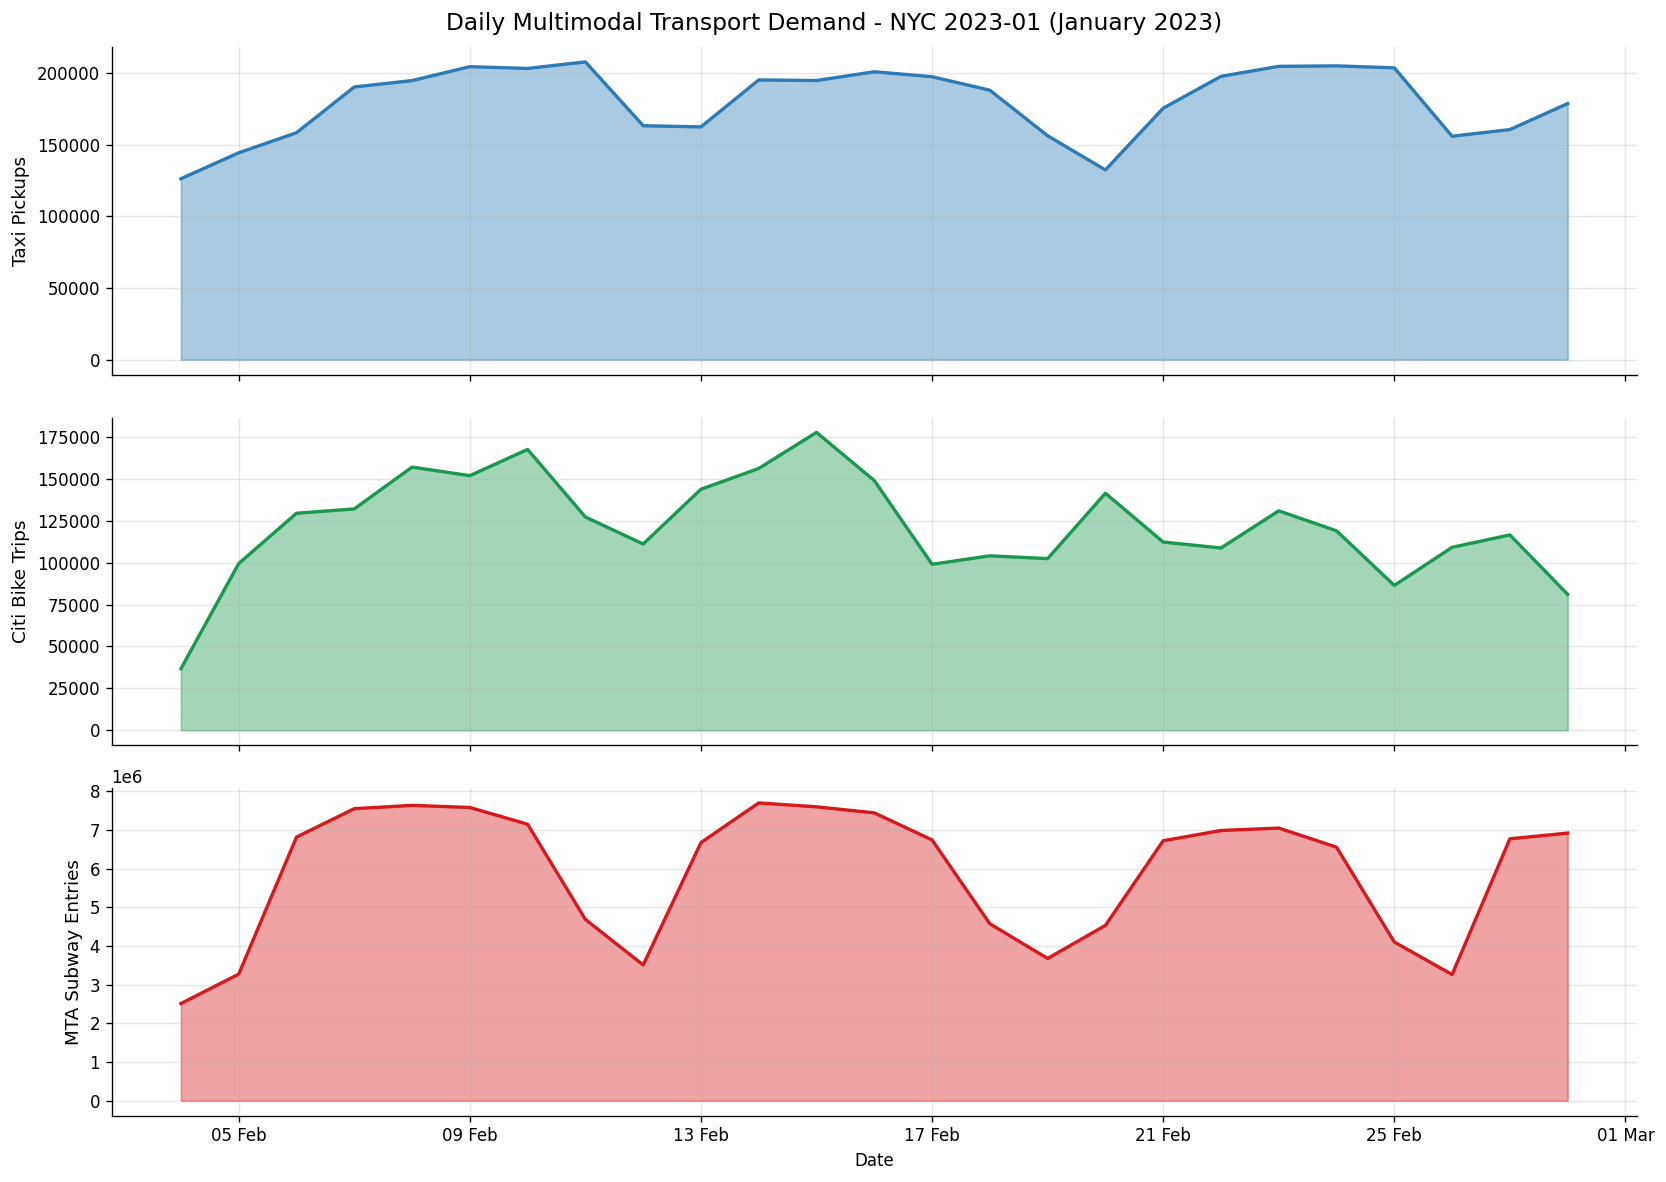

In [14]:
# ── CELL 17: Daily demand per mode ───────────────────────────────────────────
df_daily = (
    df_master.set_index("time_bin")
    .resample("D")[["taxi_demand", "bike_demand", "mta_demand"]]
    .sum()
)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

colors = ["#2C7BB6", "#1A9850", "#D7191C"]
labels = ["Taxi Pickups", "Citi Bike Trips", "MTA Subway Entries"]

for ax, col, color, label in zip(axes, df_daily.columns, colors, labels):
    ax.fill_between(df_daily.index, df_daily[col], alpha=0.4, color=color)
    ax.plot(df_daily.index, df_daily[col], color=color, linewidth=2)
    ax.set_ylabel(label, fontsize=11)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Date")
fig.suptitle(
    f"Daily Multimodal Transport Demand - NYC {YEAR}-{MONTH_STR} (January 2023)",
    fontsize=14,
)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))

plt.tight_layout()
plt.savefig(FIGURES / "01_daily_demand_per_mode.png", bbox_inches="tight", dpi=200)
plt.show()

# Interpretation notes:
# - Weekdays usually show higher demand (especially MTA and Taxi)
# - Weekends often have noticeable dips
# - Look for correlated drops across modes on bad weather days (snow, heavy rain)
# - MTA scale is in millions while others are in thousands — this is expected

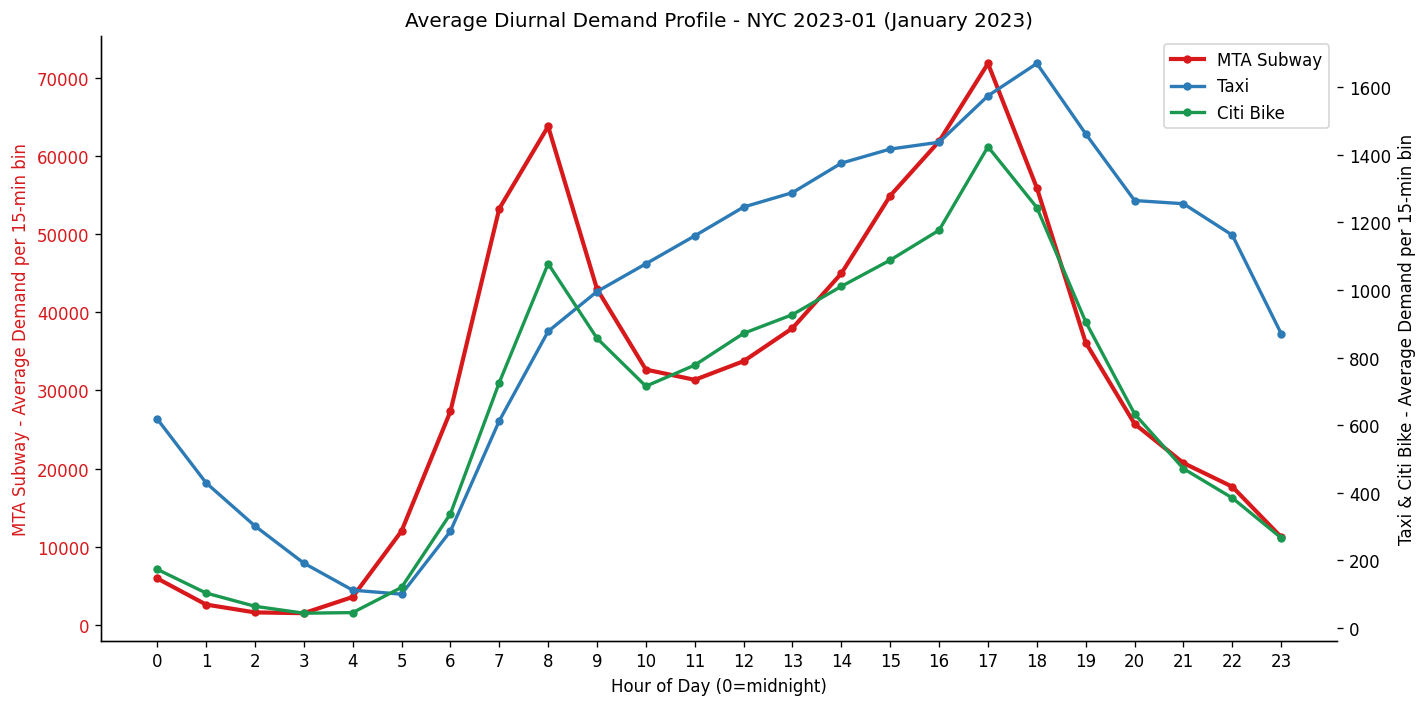

In [15]:
# ── IMPROVED: Hourly demand profile (diurnal pattern) ───────────────────────
# Assuming df_master is your final dataframe from Cell 14
df_hourly = df_master.groupby(df_master["time_bin"].dt.hour)[
    ["taxi_demand", "bike_demand", "mta_demand"]
].mean()

fig, ax1 = plt.subplots(figsize=(12, 6))

# MTA Subway - Primary axis (left)
ax1.plot(
    df_hourly.index,
    df_hourly["mta_demand"],
    marker="o",
    markersize=4,
    color="#D7191C",
    linewidth=2.5,
    label="MTA Subway",
)
ax1.set_xlabel("Hour of Day (0=midnight)")
ax1.set_ylabel("MTA Subway - Average Demand per 15-min bin", color="#D7191C")
ax1.tick_params(axis="y", labelcolor="#D7191C")
ax1.set_xticks(range(0, 24))

# Taxi + Bike - Secondary axis (right)
ax2 = ax1.twinx()
ax2.plot(
    df_hourly.index,
    df_hourly["taxi_demand"],
    marker="o",
    markersize=4,
    color="#2C7BB6",
    linewidth=2,
    label="Taxi",
)
ax2.plot(
    df_hourly.index,
    df_hourly["bike_demand"],
    marker="o",
    markersize=4,
    color="#1A9850",
    linewidth=2,
    label="Citi Bike",
)
ax2.set_ylabel("Taxi & Citi Bike - Average Demand per 15-min bin")

# Title and legend
ax1.set_title(f"Average Diurnal Demand Profile - NYC {YEAR}-{MONTH_STR} (January 2023)")

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.tight_layout()
plt.savefig(FIGURES / "02_diurnal_demand_profile.png", bbox_inches="tight", dpi=200)
plt.show()

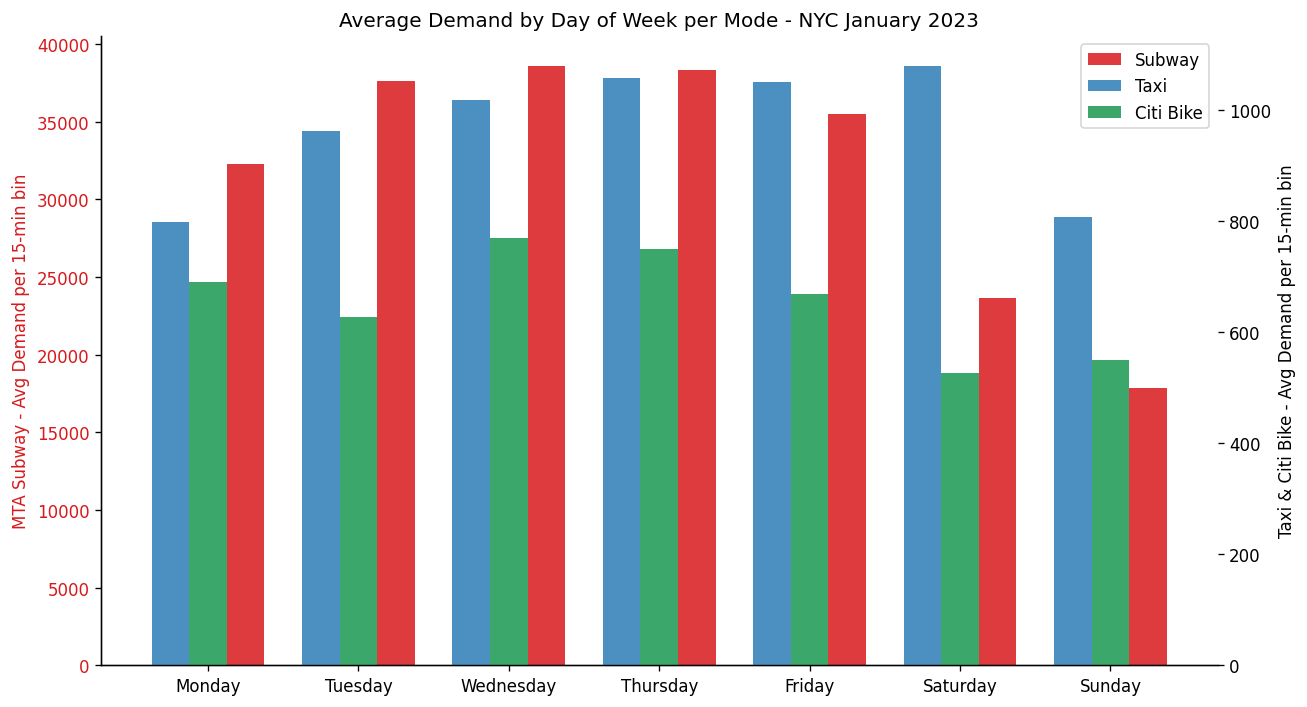

In [16]:
# ── CELL 19: Day-of-week pattern ─────────────────────────────────────────────
# Add day-of-week if not already present
if "dow" not in df_master.columns:
    df_master["dow"] = df_master["time_bin"].dt.dayofweek

df_dow = df_master.groupby("dow")[["taxi_demand", "bike_demand", "mta_demand"]].mean()

dow_labels = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

fig, ax1 = plt.subplots(figsize=(11, 6))

x = np.arange(7)
w = 0.25

# Subway on primary axis (left)
ax1.bar(x + w, df_dow["mta_demand"], w, label="Subway", color="#D7191C", alpha=0.85)
ax1.set_ylabel("MTA Subway - Avg Demand per 15-min bin", color="#D7191C")
ax1.tick_params(axis="y", labelcolor="#D7191C")

# Taxi + Bike on secondary axis (right)
ax2 = ax1.twinx()
ax2.bar(x - w, df_dow["taxi_demand"], w, label="Taxi", color="#2C7BB6", alpha=0.85)
ax2.bar(x, df_dow["bike_demand"], w, label="Citi Bike", color="#1A9850", alpha=0.85)
ax2.set_ylabel("Taxi & Citi Bike - Avg Demand per 15-min bin")

# Formatting
ax1.set_xticks(x)
ax1.set_xticklabels(dow_labels)
ax1.set_title("Average Demand by Day of Week per Mode - NYC January 2023")

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.tight_layout()
plt.savefig(FIGURES / "03_dow_demand.png", bbox_inches="tight", dpi=200)
plt.show()

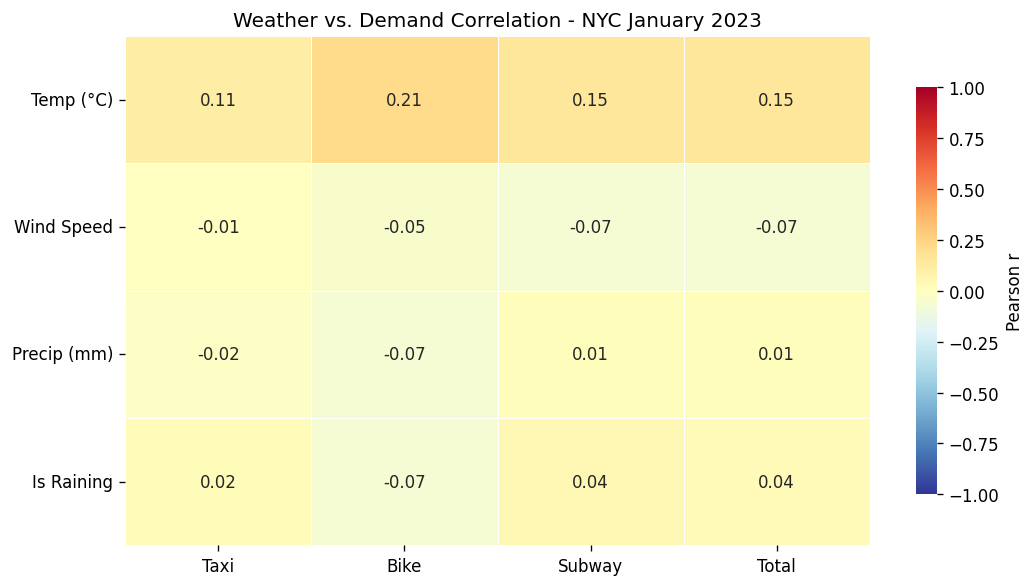


Correlation table (rounded):
            taxi_demand  bike_demand  mta_demand  total_demand
temp_c            0.111        0.213       0.151         0.153
wind_speed       -0.006       -0.045      -0.069        -0.068
precip_mm        -0.021       -0.068       0.014         0.012
is_raining        0.017       -0.068       0.041         0.038


In [17]:
# ── CELL 20: Weather correlation heatmap ─────────────────────────────────────
# Weather vs. Demand Correlation (using existing total_demand)

weather_cols = ["temp_c", "wind_speed", "precip_mm", "is_raining"]
demand_cols = ["taxi_demand", "bike_demand", "mta_demand", "total_demand"]

# Only use weather columns that actually exist and have variation
available_weather = [
    c for c in weather_cols if c in df_master.columns and df_master[c].std() > 0.01
]

corr_df = df_master[available_weather + demand_cols].corr()

# Extract only weather rows vs demand columns
corr_sub = corr_df.loc[available_weather, demand_cols]

# Plot
fig, ax = plt.subplots(figsize=(9, 5))

sns.heatmap(
    corr_sub,
    annot=True,
    fmt=".2f",
    cmap="RdYlBu_r",  # reversed: positive = blue, negative = red
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax,
    linewidths=0.6,
    cbar_kws={"label": "Pearson r", "shrink": 0.8},
)

ax.set_title("Weather vs. Demand Correlation - NYC January 2023")
ax.set_xticklabels(["Taxi", "Bike", "Subway", "Total"], rotation=0)
ax.set_yticklabels(["Temp (°C)", "Wind Speed", "Precip (mm)", "Is Raining"], rotation=0)

plt.tight_layout()
plt.savefig(FIGURES / "04_weather_demand_correlation.png", bbox_inches="tight", dpi=200)
plt.show()

print("\nCorrelation table (rounded):")
print(corr_sub.round(3))

# What to expect:
# precip_mm and is_raining: strong NEGATIVE correlation with bike demand
# temp_c: positive correlation with bike demand (people cycle more in warmer weather)
# MTA is least weather-sensitive (underground system, captive ridership)

In [19]:
# ── CELL 21: Moran's I - Spatial Autocorrelation (Real Taxi Zones) ───────────
# This proves that taxi demand is spatially clustered → justifies GNNs

import geopandas as gpd
from libpysal.weights import Queen
from esda.moran import Moran
import pandas as pd
from pathlib import Path
import urllib.request
import zipfile

# 1. Download & extract official NYC Taxi Zones shapefile
zones_url = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zones.zip"
zones_dir = Path("data/raw/taxi_zones")
zones_dir.mkdir(parents=True, exist_ok=True)

zip_path = zones_dir / "taxi_zones.zip"
shp_path = (
    zones_dir / "taxi_zones" / "taxi_zones.shp"
)  # ← this is the correct nested path

if not shp_path.exists():
    print("Downloading official NYC Taxi Zones shapefile...")
    urllib.request.urlretrieve(zones_url, zip_path)

    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(zones_dir)
        print("Extracted files:", z.namelist())  # for debugging

    print("✅ Shapefile downloaded and extracted.")

# 2. Load zones with real geometry
zones = gpd.read_file(shp_path)
zones = zones.rename(columns={"LocationID": "PULocationID"})  # match your taxi data

print(f"Loaded {len(zones)} taxi zones")

# 3. Load your cleaned taxi data and compute average daily demand per zone
df_taxi = pd.read_parquet(
    Path("data/processed") / f"taxi_clean_{YEAR}_all_months.parquet"
)

zone_demand = df_taxi.groupby("PULocationID").size().reset_index(name="total_trips")

num_days = df_taxi["pickup_dt"].dt.date.nunique()
zone_demand["avg_demand"] = zone_demand["total_trips"] / num_days

# Merge demand onto zones
zones = zones.merge(zone_demand, on="PULocationID", how="left")
zones["avg_demand"] = zones["avg_demand"].fillna(0)

print(f"Average daily taxi demand calculated across {num_days} days")

# 4. Create real spatial weights matrix (Queen = shares any border)
weights = Queen.from_dataframe(zones, ids=zones["PULocationID"])

# 5. Compute Global Moran's I
moran = Moran(zones["avg_demand"], weights)

print(f"\n{'='*60}")
print(f"Global Moran's I          : {moran.I:.4f}")
print(f"p-value                   : {moran.p_sim:.4f}")
print(f"{'='*60}")

if moran.I > 0.2 and moran.p_sim < 0.05:
    print("✅ STRONG POSITIVE SPATIAL AUTOCORRELATION DETECTED!")
    print("   High-demand zones tend to cluster together spatially.")
    print("   → This strongly justifies using Graph Neural Networks (GNNs)")
    print("     in the zone-level modeling phase.")
else:
    print("⚠️  Weak spatial autocorrelation detected.")

Loaded 263 taxi zones
Average daily taxi demand calculated across 59 days
('WARNING: ', 1, ' is an island (no neighbors)')
('WARNING: ', 46, ' is an island (no neighbors)')
('WARNING: ', 103, ' is an island (no neighbors)')
('WARNING: ', 104, ' is an island (no neighbors)')
('WARNING: ', 105, ' is an island (no neighbors)')
('WARNING: ', 202, ' is an island (no neighbors)')

Global Moran's I          : 0.8075
p-value                   : 0.0010
✅ STRONG POSITIVE SPATIAL AUTOCORRELATION DETECTED!
   High-demand zones tend to cluster together spatially.
   → This strongly justifies using Graph Neural Networks (GNNs)
     in the zone-level modeling phase.


c:\Users\DELL\Pictures\RESEARCH\maas-research\.venv\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 10 disconnected components.
 There are 6 islands with ids: 1, 46, 103, 104, 105, 202.
  W.__init__(self, neighbors, ids=ids, **kw)


In [38]:
zones

,OBJECTID,Shape_Leng,Shape_Area,zone,PULocationID,borough,geometry,total_trips,avg_demand
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19...",13.0,0.220339
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343...",1.0,0.016949
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2...",45.0,0.762712
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20...",6911.0,117.135593
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144...",2.0,0.033898
...,...,...,...,...,...,...,...,...,...
258,259,0.126750,0.000395,Woodlawn/Wakefield,259,Bronx,"POLYGON ((1025414.782 270986.139, 1025138.624 ...",63.0,1.067797
259,260,0.133514,0.000422,Woodside,260,Queens,"POLYGON ((1011466.966 216463.005, 1011545.889 ...",941.0,15.949153
260,261,0.027120,0.000034,World Trade Center,261,Manhattan,"POLYGON ((980555.204 196138.486, 980570.792 19...",22712.0,384.949153
261,262,0.049064,0.000122,Yorkville East,262,Manhattan,"MULTIPOLYGON (((999804.795 224498.527, 999824....",81396.0,1379.593220


In [24]:
# ── CELL 24: Prophet Baseline ────────────────────────────────────────────────
import pandas as pd
from prophet import Prophet
import warnings
from pathlib import Path
import joblib

warnings.filterwarnings("ignore")

YEAR, MONTH = 2023, 1
MONTH_STR = f"{MONTH:02d}"
FIGURES = Path("outputs/figures")
MODELS = Path("models")
FIGURES.mkdir(parents=True, exist_ok=True)
MODELS.mkdir(parents=True, exist_ok=True)

# Load master data
df_master = pd.read_parquet(
    Path("data/processed") / f"master_{YEAR}_all.parquet"
)
df_master["time_bin"] = pd.to_datetime(df_master["time_bin"])

TARGET = "taxi_demand"

# Prophet requires columns: ds (datetime) and y (target)
prophet_df = df_master[["time_bin", TARGET]].rename(
    columns={"time_bin": "ds", TARGET: "y"}
)

# Train/Test Split (same as ARIMA)
TEST_STEPS = 672
train_df = prophet_df.iloc[:-TEST_STEPS].copy()
test_df  = prophet_df.iloc[-TEST_STEPS:].copy()

print(f"Train: {len(train_df):,} rows ({train_df['ds'].min().date()} to {train_df['ds'].max().date()})")
print(f"Test:  {len(test_df):,} rows ({test_df['ds'].min().date()} to {test_df['ds'].max().date()})")

# ── Fit Prophet Model ────────────────────────────────────────────────────────
print("\nFitting Prophet model...")

model = Prophet(
    daily_seasonality=True,      # important for 15-min data
    weekly_seasonality=True,
    yearly_seasonality=False,    # only one month of data
    seasonality_mode='multiplicative',
    seasonality_prior_scale=10,
    changepoint_prior_scale=0.05,
    holidays_prior_scale=10,
)

model.fit(train_df)

print("✅ Prophet model fitted successfully")

Train: 4,032 rows (2023-02-04 to 2023-02-25)
Test:  672 rows (2023-02-25 to 2023-02-28)

Fitting Prophet model...


07:02:06 - cmdstanpy - INFO - Chain [1] start processing
07:02:07 - cmdstanpy - INFO - Chain [1] done processing


✅ Prophet model fitted successfully


In [35]:
# ── CELL 24: Prophet Baseline + NYC Holidays ────────────────────────────────
import pandas as pd
from prophet import Prophet
import warnings
from pathlib import Path
import joblib

warnings.filterwarnings("ignore")

YEAR, MONTH = 2023, 1
MONTH_STR = f"{MONTH:02d}"
FIGURES = Path("outputs/figures")
MODELS = Path("models")
FIGURES.mkdir(parents=True, exist_ok=True)
MODELS.mkdir(parents=True, exist_ok=True)

# Load master data
df_master = pd.read_parquet(
    Path("data/processed") / f"master_{YEAR}_all.parquet"
)
df_master["time_bin"] = pd.to_datetime(df_master["time_bin"])

TARGET = "taxi_demand"

# Prophet format: ds and y
prophet_df = df_master[["time_bin", TARGET]].rename(
    columns={"time_bin": "ds", TARGET: "y"}
)

# Train/Test Split (same as before)
TEST_STEPS = 672
train_df = prophet_df.iloc[:-TEST_STEPS].copy()
test_df  = prophet_df.iloc[-TEST_STEPS:].copy()

print(f"Train: {len(train_df):,} rows")
print(f"Test:  {len(test_df):,} rows")

# ── Define NYC Holidays for January 2023 ─────────────────────────────────────
holidays = pd.DataFrame({
    'holiday': ['New Year','GRDHOGBDAY', 'MLK Day','LUNAR','lINBDAY','VAL-DAY','WASHBDAY'],
    'ds': pd.to_datetime(['2023-01-01','2023-01-02', '2023-01-16', '2023-01-22','2023-02-13','2023-02-14', '2023-02-20']),
    'lower_window': -1,   # include day before
    'upper_window': 1,    # include day after
})

# ── Fit Prophet Model with Holidays ──────────────────────────────────────────
print("\nFitting Prophet model with holidays...")

# model = Prophet(
#     daily_seasonality=True,
#     weekly_seasonality=True,
#     yearly_seasonality=False,
#     seasonality_mode='multiplicative',
#     seasonality_prior_scale=10,
#     changepoint_prior_scale=0.05,
#     holidays_prior_scale=10,
#     holidays=holidays,           # ← holidays added here
# )
model = Prophet(
    daily_seasonality=False,   # turn this OFF
    weekly_seasonality=True,
    yearly_seasonality=False,
    seasonality_mode='multiplicative',
    seasonality_prior_scale=10,
    changepoint_prior_scale=0.05,
    holidays_prior_scale=10,
    holidays=holidays,
)

# 🔥 KEY FIX
model.add_seasonality(
    name='daily_15min',
    period=1,          # 1 day
    fourier_order=20   # higher = more flexible curve
)
model.add_seasonality(
    name='weekly',
    period=7,
    fourier_order=10
)
model.fit(train_df)

print("✅ Prophet model with holidays fitted successfully")

Train: 4,032 rows
Test:  672 rows

Fitting Prophet model with holidays...


07:30:44 - cmdstanpy - INFO - Chain [1] start processing
07:30:45 - cmdstanpy - INFO - Chain [1] done processing


✅ Prophet model with holidays fitted successfully


Prophet Performance on Test Set (with all holidays):
  MAE:  682.75
  RMSE: 848.03
  MAPE: 473.92%


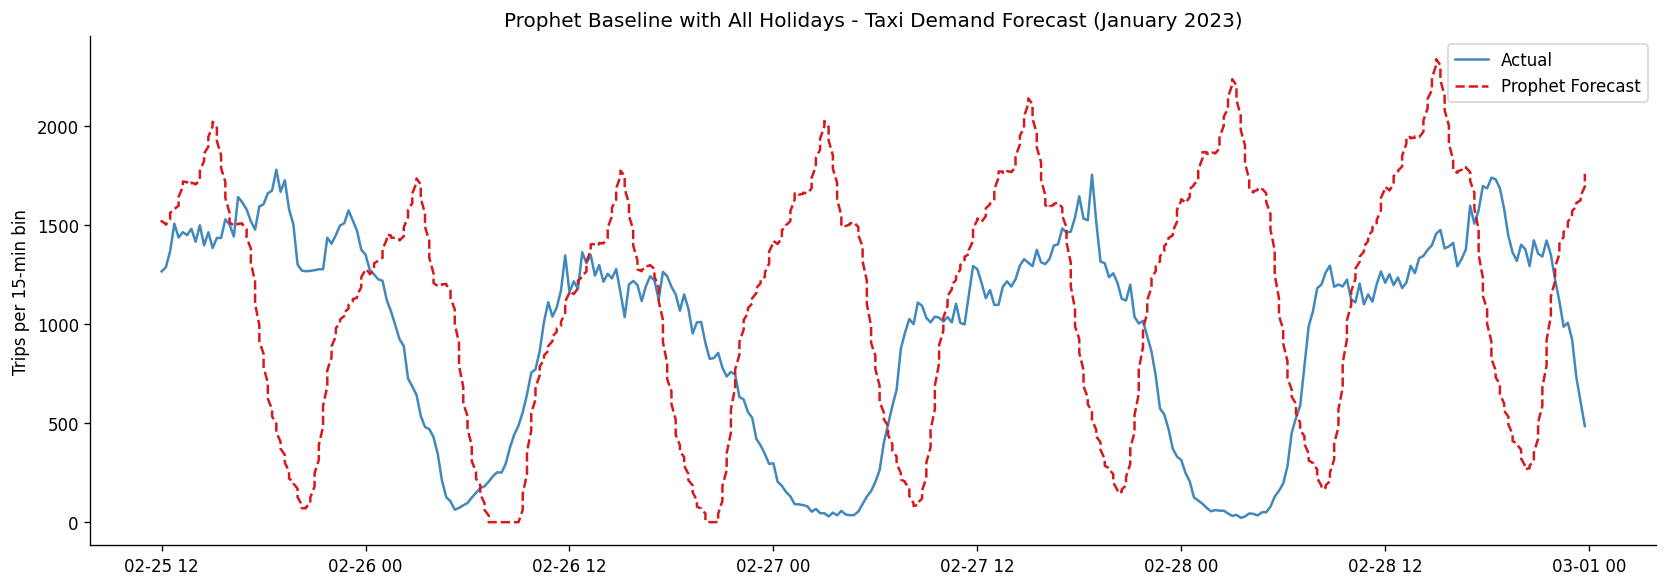


✅ Final Prophet model with holidays saved.


In [36]:
# ── CELL 25: Prophet Forecast and Evaluation (Final) ─────────────────────────
future = model.make_future_dataframe(periods=TEST_STEPS, freq="15min")
forecast = model.predict(future)

prophet_forecast = forecast.iloc[-TEST_STEPS:]["yhat"].values
prophet_forecast = np.maximum(prophet_forecast, 0)

actual = test_df["y"].values

# Metrics
def mae(y_true, y_pred):    return np.mean(np.abs(y_true - y_pred))
def rmse(y_true, y_pred):   return np.sqrt(np.mean((y_true - y_pred) ** 2))
def mape(y_true, y_pred):
    mask = y_true > 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

prophet_mae  = mae(actual, prophet_forecast)
prophet_rmse = rmse(actual, prophet_forecast)
prophet_mape = mape(actual, prophet_forecast)

print("Prophet Performance on Test Set (with all holidays):")
print(f"  MAE:  {prophet_mae:.2f}")
print(f"  RMSE: {prophet_rmse:.2f}")
print(f"  MAPE: {prophet_mape:.2f}%")

# Plot
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_df["ds"], actual, color="#2C7BB6", linewidth=1.5, label="Actual", alpha=0.9)
ax.plot(test_df["ds"], prophet_forecast, color="#D7191C", linewidth=1.5,
        linestyle="--", label="Prophet Forecast")

ax.set_title("Prophet Baseline with All Holidays - Taxi Demand Forecast (January 2023)")
ax.set_ylabel("Trips per 15-min bin")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / "06_prophet_final_with_holidays.png", bbox_inches="tight", dpi=200)
plt.show()

# Save
results = {
    "model": "Prophet_With_All_Holidays",
    "MAE": prophet_mae,
    "RMSE": prophet_rmse,
    "MAPE": prophet_mape
}
pd.DataFrame([results]).to_csv(
    Path("outputs/results") / "prophet_final_results.csv", index=False
)
joblib.dump(model, Path("models") / "prophet_with_holidays.pkl")
print("\n✅ Final Prophet model with holidays saved.")

In [26]:
# ── CELL 24: Prepare Features for Gradient Boosting ──────────────────────────
import pandas as pd
import numpy as np
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

YEAR, MONTH = 2023, 1
MONTH_STR = f"{MONTH:02d}"

# Load the correct master file
df = pd.read_parquet(
    Path("data/processed") / f"master_{YEAR}_all.parquet"
)
df["time_bin"] = pd.to_datetime(df["time_bin"])

TARGET = "taxi_demand"

# Include bike_demand and mta_demand as features (they are strong predictors)
EXCLUDE = ["time_bin", TARGET]
FEATURE_COLS = [c for c in df.columns if c not in EXCLUDE]

print(f"Target: {TARGET}")
print(f"Number of features: {len(FEATURE_COLS)}")
print("Features include bike_demand and mta_demand: Yes")

Target: taxi_demand
Number of features: 52
Features include bike_demand and mta_demand: Yes


In [27]:
# ── CELL 25: Train/Test Split + Scaling ──────────────────────────────────────
from sklearn.preprocessing import StandardScaler

TEST_STEPS = 672  # last 7 days

X = df[FEATURE_COLS].values
y = df[TARGET].values

# Temporal split (no shuffling)
X_train, X_test = X[:-TEST_STEPS], X[-TEST_STEPS:]
y_train, y_test = y[:-TEST_STEPS], y[-TEST_STEPS:]

# Scaling (kept for consistency with future LSTM)
scaler_X = StandardScaler()
X_train_s = scaler_X.fit_transform(X_train)
X_test_s  = scaler_X.transform(X_test)

# Validation split for early stopping
val_size = int(len(X_train) * 0.15)
X_tr, X_val = X_train_s[:-val_size], X_train_s[-val_size:]
y_tr, y_val = y_train[:-val_size], y_train[-val_size:]

print(f"Training samples: {len(X_tr)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples: {len(X_test)}")

Training samples: 3428
Validation samples: 604
Test samples: 672


In [28]:
# ── CELL 26: Train XGBoost ───────────────────────────────────────────────────
import xgboost as xgb

print("Training XGBoost...")

xgb_model = xgb.XGBRegressor(
    n_estimators=1000,
    max_depth=8,
    learning_rate=0.03,
    subsample=0.85,
    colsample_bytree=0.75,
    reg_alpha=0.05,
    reg_lambda=1.0,
    min_child_weight=5,
    random_state=42,
    n_jobs=-1,
    eval_metric="mae",
    early_stopping_rounds=60,
    verbosity=0
)

xgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=50
)

print("XGBoost training completed.")

Training XGBoost...
[0]	validation_0-mae:525.52736
[50]	validation_0-mae:122.59725
[100]	validation_0-mae:41.28036
[150]	validation_0-mae:28.04780
[200]	validation_0-mae:26.31113
[250]	validation_0-mae:25.90668
[300]	validation_0-mae:25.87122
[350]	validation_0-mae:25.72510
[400]	validation_0-mae:25.75797
[410]	validation_0-mae:25.75151
XGBoost training completed.


In [30]:
# ── CELL 27: Train LightGBM ──────────────────────────────────────────────────
import lightgbm as lgb

print("Training LightGBM...")

lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,
    num_leaves=128,
    learning_rate=0.03,
    subsample=0.85,
    colsample_bytree=0.75,
    reg_alpha=0.05,
    reg_lambda=1.0,
    min_child_samples=20,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(60, verbose=False), lgb.log_evaluation(50)]
)

print("LightGBM training completed.")

Training LightGBM...
[50]	valid_0's l2: 20741.1
[100]	valid_0's l2: 2748.56
[150]	valid_0's l2: 1529.37
[200]	valid_0's l2: 1328.04
[250]	valid_0's l2: 1263.86
[300]	valid_0's l2: 1239.46
[350]	valid_0's l2: 1234.64
[400]	valid_0's l2: 1229.67
[450]	valid_0's l2: 1225.89
[500]	valid_0's l2: 1224.62
[550]	valid_0's l2: 1220.36
LightGBM training completed.


XGBoost:  MAE=22.84 | RMSE=33.39 | MAPE=4.00%
LightGBM:  MAE=22.84 | RMSE=33.23 | MAPE=3.87%


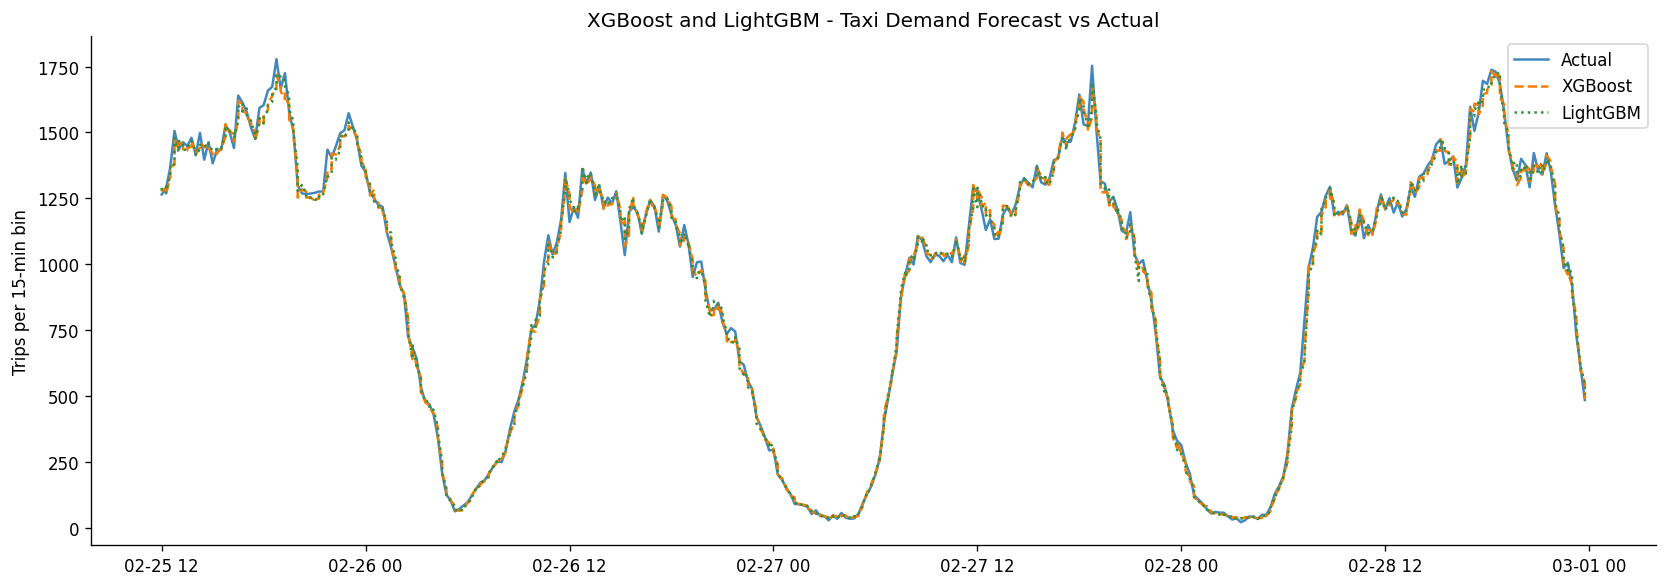

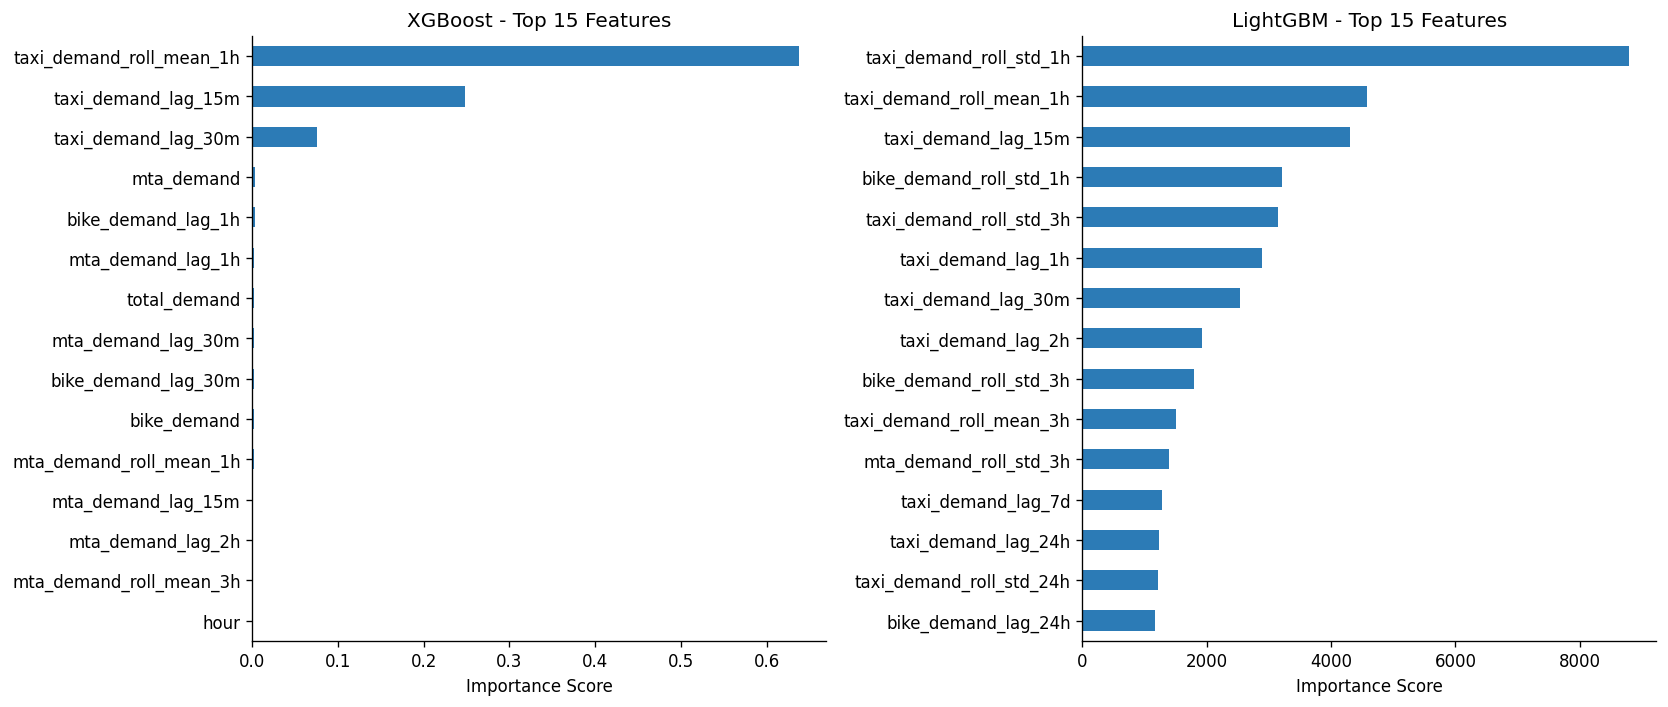


✅ All models, results, and plots saved successfully.


In [31]:
# ── CELL 28: Evaluate and Visualise Results ──────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import joblib
from pathlib import Path
import pandas as pd

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def mape(y_true, y_pred):
    mask = y_true > 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

# Predictions
xgb_pred = np.maximum(xgb_model.predict(X_test_s), 0)
lgb_pred = np.maximum(lgb_model.predict(X_test_s), 0)

# Results
results_list = []
for name, pred in [("XGBoost", xgb_pred), ("LightGBM", lgb_pred)]:
    m = {
        "model": name,
        "MAE": mae(y_test, pred),
        "RMSE": rmse(y_test, pred),
        "MAPE": mape(y_test, pred),
    }
    results_list.append(m)
    print(f"{name}:  MAE={m['MAE']:.2f} | RMSE={m['RMSE']:.2f} | MAPE={m['MAPE']:.2f}%")

pd.DataFrame(results_list).to_csv(
    Path("outputs/results") / "gbm_results.csv", index=False
)

# Plot Forecast vs Actual
test_index = df["time_bin"].iloc[-TEST_STEPS:]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_index.values, y_test, color="#2C7BB6", linewidth=1.5, label="Actual", alpha=0.9)
ax.plot(test_index.values, xgb_pred, color="#F57C00", linewidth=1.5, linestyle="--", label="XGBoost")
ax.plot(test_index.values, lgb_pred, color="#388E3C", linewidth=1.5, linestyle=":", label="LightGBM")

ax.set_title("XGBoost and LightGBM - Taxi Demand Forecast vs Actual")
ax.set_ylabel("Trips per 15-min bin")
ax.legend()
plt.tight_layout()
plt.savefig(Path("outputs/figures") / "06_gbm_forecast.png", bbox_inches="tight", dpi=200)
plt.show()

# Feature Importance
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, model, name in zip(axes, [xgb_model, lgb_model], ["XGBoost", "LightGBM"]):
    importance = pd.Series(model.feature_importances_, index=FEATURE_COLS)
    importance.nlargest(15).sort_values().plot(kind="barh", ax=ax, color="#2C7BB6")
    ax.set_title(f"{name} - Top 15 Features")
    ax.set_xlabel("Importance Score")

plt.tight_layout()
plt.savefig(Path("outputs/figures") / "07_gbm_feature_importance.png", bbox_inches="tight", dpi=200)
plt.show()

# Save everything
joblib.dump(xgb_model, Path("models") / "xgb_model.pkl")
joblib.dump(lgb_model, Path("models") / "lgb_model.pkl")
joblib.dump(scaler_X, Path("models") / "scaler_X.pkl")

print("\n✅ All models, results, and plots saved successfully.")

Loaded master_2023_all.parquet
Using 17 features: ['taxi_demand', 'bike_demand_lag_15m', 'mta_demand_lag_15m', 'temp_c', 'wind_speed', 'precip_mm', 'is_raining', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'is_weekend', 'taxi_demand_lag_15m', 'taxi_demand_lag_1h', 'taxi_demand_lag_24h', 'taxi_demand_roll_mean_1h', 'taxi_demand_roll_std_1h']
Train sequences shape: (3936, 96, 17) (samples, timesteps, features)
Test sequences shape:  (576, 96, 17)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 96, 64)         │        20,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,953 (132.63 KB)

 Trainable params: 33,953 (132.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 18s 108ms/step - loss: 924.2319 - mse: 1155108.0000 - val_loss: 1064.4412 - val_mse: 1483239.0000 - learning_rate: 0.0010
Epoch 2/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 11s 101ms/step - loss: 913.9257 - mse: 1136240.7500 - val_loss: 1051.9150 - val_mse: 1456729.7500 - learning_rate: 0.0010
Epoch 3/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 12s 112ms/step - loss: 898.9026 - mse: 1108979.5000 - val_loss: 1034.4910 - val_mse: 1420366.3750 - learning_rate: 0.0010
Epoch 4/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 11s 101ms/step - loss: 879.7847 - mse: 1073461.3750 - val_loss: 1012.3273 - val_mse: 1374175.1250 - learning_rate: 0.0010
Epoch 5/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 11s 100ms/step - loss: 857.5512 - mse: 1030163.4375 - val_loss: 987.3472 - val_mse: 1320072.5000 - learning_rate: 0.0010
Epoch 6/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 11s 101ms/step - loss: 834.2982 - mse: 982291.5625 - val_loss: 960.6699 - val_mse: 1259250.1250 - learning_rate: 0.0010
Epoch 7/100
105/105 ━━━━━

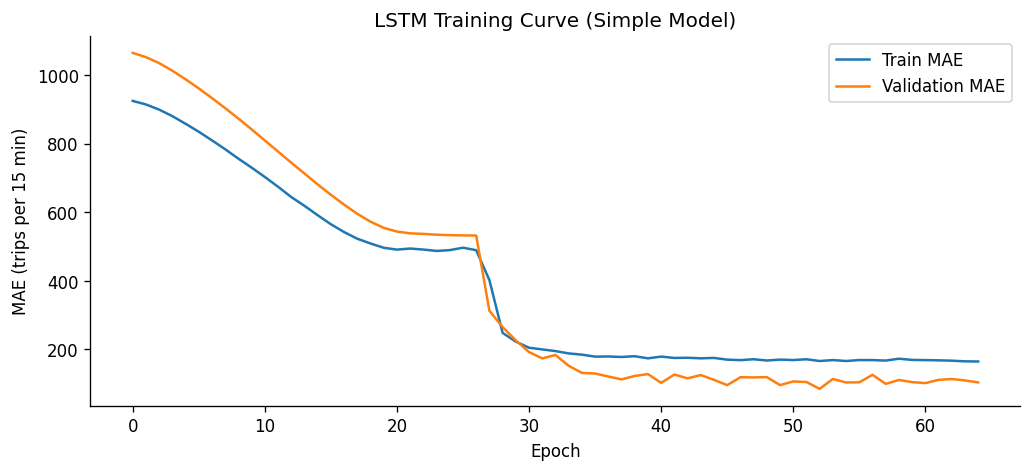


SIMPLE LSTM PERFORMANCE (Raw Target, No Log, No Look-ahead)
MAE:  58.21
RMSE: 79.39
MAPE: 9.88%


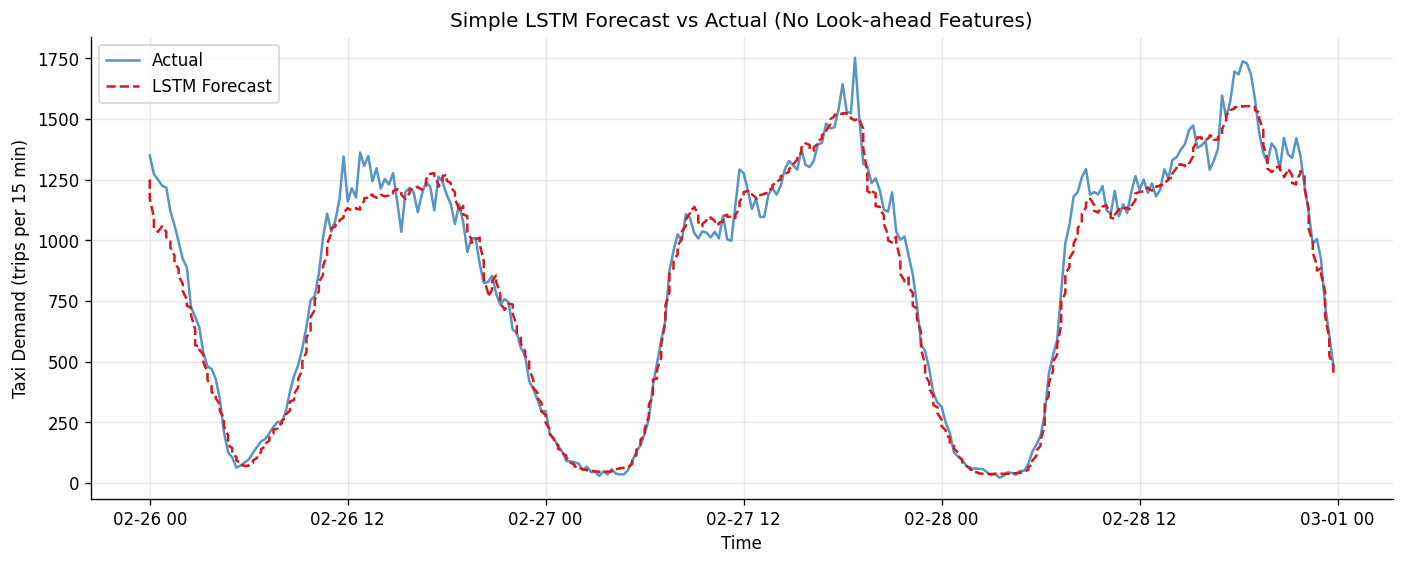

✅ All done. Model, scaler, results, and plots saved.


In [ ]:
# ──────────────────────────────────────────────────────────────────────────────
# LSTM IMPLEMENTATION
# ──────────────────────────────────────────────────────────────────────────────

# 0. Imports & configuration
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import joblib

# Set seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Paths
DATA_DIR = Path("data/processed")
MODEL_DIR = Path("models")
FIGURE_DIR = Path("outputs/figures")
RESULT_DIR = Path("outputs/results")
MODEL_DIR.mkdir(exist_ok=True, parents=True)
FIGURE_DIR.mkdir(exist_ok=True, parents=True)
RESULT_DIR.mkdir(exist_ok=True, parents=True)

TARGET = "taxi_demand"
LOOKBACK = 96          # 24 hours (15-min intervals)
TEST_STEPS = 672       # 7 days

# ------------------------------------------------------------------------------
# 1. Load data (January and Feb 2023 only, but extensible)
# ------------------------------------------------------------------------------
def load_data(years_months):
    df_list = []
    for year, month in years_months:
        fname = f"master_{year}_all.parquet"
        fpath = DATA_DIR / fname
        if fpath.exists():
            df = pd.read_parquet(fpath)
            df["time_bin"] = pd.to_datetime(df["time_bin"])
            df_list.append(df)
            print(f"Loaded {fname}")
        else:
            print(f"Warning: {fname} not found")
    if not df_list:
        raise FileNotFoundError("No data files found!")
    df = pd.concat(df_list, ignore_index=True)
    df = df.sort_values("time_bin").reset_index(drop=True)
    return df

df = load_data([(2023, 1)])

# ------------------------------------------------------------------------------
# 2. Feature selection (no look‑ahead bias)
# ------------------------------------------------------------------------------
# Use only features that would be known at prediction time:
# - current taxi_demand (we predict next step)
# - lagged bike/mta demand (not the current value)
# - weather, time features, rolling statistics (all computed from past)
FEATURES = [
    TARGET,                     # current demand
    "bike_demand_lag_15m",
    "mta_demand_lag_15m",
    "temp_c",
    "wind_speed",
    "precip_mm",
    "is_raining",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "is_weekend",
    "taxi_demand_lag_15m",
    "taxi_demand_lag_1h",
    "taxi_demand_lag_24h",
    "taxi_demand_roll_mean_1h",
    "taxi_demand_roll_std_1h",
]

# Keep only those that exist in the dataframe
FEATURES = [f for f in FEATURES if f in df.columns]
print(f"Using {len(FEATURES)} features: {FEATURES}")

# Drop rows with missing values (first few rows after lags)
df = df.dropna(subset=FEATURES).reset_index(drop=True)

# ------------------------------------------------------------------------------
# 3. Train/test split (before scaling) – NO DATA LEAKAGE
# ------------------------------------------------------------------------------
data_raw = df[FEATURES].values.astype(np.float32)
target_idx = FEATURES.index(TARGET)
X_all = data_raw
y_all = data_raw[:, target_idx]

train_size = len(X_all) - TEST_STEPS
X_train_raw = X_all[:train_size]
X_test_raw = X_all[train_size:]
y_train_raw = y_all[:train_size]
y_test_raw = y_all[train_size:]

# Scale features only (target remains raw, so no inverse transform needed)
scaler_X = MinMaxScaler()
scaler_X.fit(X_train_raw)
X_train_scaled = scaler_X.transform(X_train_raw)
X_test_scaled = scaler_X.transform(X_test_raw)

# Save feature scaler for later use (if needed)
joblib.dump(scaler_X, MODEL_DIR / "scaler_X_lstm.pkl")

# ------------------------------------------------------------------------------
# 4. Create sliding window sequences
# ------------------------------------------------------------------------------
def make_sequences(X, y, lookback):
    X_seq, y_seq = [], []
    for i in range(lookback, len(X)):
        X_seq.append(X[i-lookback:i, :])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)

X_train_seq, y_train_seq = make_sequences(X_train_scaled, y_train_raw, LOOKBACK)
X_test_seq, y_test_seq = make_sequences(X_test_scaled, y_test_raw, LOOKBACK)

print(f"Train sequences shape: {X_train_seq.shape} (samples, timesteps, features)")
print(f"Test sequences shape:  {X_test_seq.shape}")

# ------------------------------------------------------------------------------
# 5. Build simple LSTM model
# ------------------------------------------------------------------------------
model = Sequential([
    Input(shape=(LOOKBACK, len(FEATURES))),
    LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.2),
    LSTM(32, return_sequences=False, dropout=0.2, recurrent_dropout=0.2),
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(1)
])

optimizer = Adam(learning_rate=0.001, clipnorm=1.0)
model.compile(optimizer=optimizer, loss='mae', metrics=['mse'])
model.summary()

# ------------------------------------------------------------------------------
# 6. Train with explicit validation split (last 15% of training sequences)
# ------------------------------------------------------------------------------
val_split = int(len(X_train_seq) * 0.15)
X_tr = X_train_seq[:-val_split]
y_tr = y_train_seq[:-val_split]
X_val = X_train_seq[-val_split:]
y_val = y_train_seq[-val_split:]

callbacks = [
    EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)
]

history = model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

# Plot training curve
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train MAE')
plt.plot(history.history['val_loss'], label='Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE (trips per 15 min)')
plt.title('LSTM Training Curve (Simple Model)')
plt.legend()
plt.savefig(FIGURE_DIR / 'lstm_simple_training.png', dpi=200)
plt.show()

# Save the model
model.save(MODEL_DIR / 'lstm_simple.keras')

# ------------------------------------------------------------------------------
# 7. Evaluate on test set
# ------------------------------------------------------------------------------
pred_raw = model.predict(X_test_seq, verbose=0).flatten()
pred_raw = np.maximum(pred_raw, 0)   # demand cannot be negative

# y_test_seq is already raw demand (no scaling on target)
y_true = y_test_seq

# Metrics
mae_val = mean_absolute_error(y_true, pred_raw)
rmse_val = np.sqrt(mean_squared_error(y_true, pred_raw))
mask = y_true > 0
mape_val = np.mean(np.abs((y_true[mask] - pred_raw[mask]) / y_true[mask])) * 100

print("\n" + "="*50)
print("SIMPLE LSTM PERFORMANCE (Raw Target, No Log, No Look-ahead)")
print("="*50)
print(f"MAE:  {mae_val:.2f}")
print(f"RMSE: {rmse_val:.2f}")
print(f"MAPE: {mape_val:.2f}%")
print("="*50)

# Save results to CSV
results_df = pd.DataFrame([{
    "model": "LSTM_Simple_32units",
    "MAE": mae_val,
    "RMSE": rmse_val,
    "MAPE": mape_val
}])
results_df.to_csv(RESULT_DIR / "lstm_simple_results.csv", index=False)

# ------------------------------------------------------------------------------
# 8. Plot forecast vs actual for the test period
# ------------------------------------------------------------------------------
# Get corresponding time bins for the test set (accounting for lookback offset)
test_start_idx = train_size + LOOKBACK
test_time_bins = df["time_bin"].iloc[test_start_idx : test_start_idx + len(y_true)]

plt.figure(figsize=(14, 5))
plt.plot(test_time_bins, y_true, label='Actual', color='#2C7BB6', alpha=0.8, linewidth=1.5)
plt.plot(test_time_bins, pred_raw, label='LSTM Forecast', color='#D7191C', linestyle='--', linewidth=1.5)
plt.xlabel('Time')
plt.ylabel('Taxi Demand (trips per 15 min)')
plt.title('Simple LSTM Forecast vs Actual (No Look-ahead Features)')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(FIGURE_DIR / 'lstm_simple_forecast.png', dpi=200)
plt.show()

print("✅ All done. Model, scaler, results, and plots saved.")

In [8]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
import joblib

# ------------------------------------------------------------------------------
# Load taxi zones shapefile and get its CRS
# ------------------------------------------------------------------------------
zones_gdf = gpd.read_file("./data/raw/taxi_zones/taxi_zones/taxi_zones.shp")
zones_gdf = zones_gdf.rename(columns={"LocationID": "zone_id"})
zones_gdf = zones_gdf[["zone_id", "geometry"]]
zones_crs = zones_gdf.crs
print(f"Zones CRS: {zones_crs}")

# ------------------------------------------------------------------------------
# Helper: spatial join with fallback to nearest zone
# ------------------------------------------------------------------------------
def map_points_to_zones(points_gdf, zones_gdf, id_col):
    """
    points_gdf: GeoDataFrame with points (geometry) and an id column.
    Returns dict {id: zone_id}
    """
    # First, ensure points are in same CRS as zones
    points_gdf = points_gdf.to_crs(zones_crs)
    
    # Spatial join (within)
    joined = gpd.sjoin(points_gdf, zones_gdf, how="left", predicate="within")
    
    # Points that found a zone
    matched = joined.dropna(subset=["zone_id"])
    matched_dict = dict(zip(matched[id_col], matched["zone_id"].astype(int)))
    
    # Points that did NOT match – assign to nearest zone
    unmatched = joined[joined["zone_id"].isna()]
    if len(unmatched) > 0:
        print(f"  {len(unmatched)} points not within any zone – assigning to nearest zone")
        nearest_zones = []
        for idx, row in unmatched.iterrows():
            # Find the nearest zone polygon
            distances = zones_gdf.distance(row.geometry)
            nearest_idx = distances.idxmin()
            nearest_zone = zones_gdf.loc[nearest_idx, "zone_id"]
            nearest_zones.append(nearest_zone)
        unmatched_dict = dict(zip(unmatched[id_col], nearest_zones))
        matched_dict.update(unmatched_dict)
    
    return matched_dict

# ------------------------------------------------------------------------------
# Bike stations
# ------------------------------------------------------------------------------
df_bike = pd.read_parquet("./data/processed/bike_clean_2023.parquet")
bike_stations = df_bike[["start_station_id", "start_lat", "start_lng"]].drop_duplicates()
bike_stations = bike_stations.dropna(subset=["start_lat", "start_lng"])
bike_stations["geometry"] = bike_stations.apply(
    lambda row: Point(row["start_lng"], row["start_lat"]), axis=1
)
bike_gdf = gpd.GeoDataFrame(bike_stations, geometry="geometry", crs="EPSG:4326")  # WGS84
bike_station_to_zone = map_points_to_zones(bike_gdf, zones_gdf, "start_station_id")
print(f"Bike stations mapped: {len(bike_station_to_zone)}")

# ------------------------------------------------------------------------------
# MTA stations
# ------------------------------------------------------------------------------
df_mta = pd.read_parquet("./data/processed/mta_clean_2023.parquet")
# Note: use station_complex_id (not name) for uniqueness
mta_stations = df_mta[["station_complex_id", "latitude", "longitude"]].drop_duplicates()
mta_stations = mta_stations.dropna(subset=["latitude", "longitude"])
mta_stations["geometry"] = mta_stations.apply(
    lambda row: Point(row["longitude"], row["latitude"]), axis=1
)
mta_gdf = gpd.GeoDataFrame(mta_stations, geometry="geometry", crs="EPSG:4326")
mta_station_to_zone = map_points_to_zones(mta_gdf, zones_gdf, "station_complex_id")
print(f"MTA stations mapped: {len(mta_station_to_zone)}")

# ------------------------------------------------------------------------------
# Save mappings
# ------------------------------------------------------------------------------
joblib.dump(bike_station_to_zone, "./data/processed/bike_station_to_zone.pkl")
joblib.dump(mta_station_to_zone, "./data/processed/mta_station_to_zone.pkl")
print("Mappings saved.")

Zones CRS: EPSG:2263
Bike stations mapped: 1873
MTA stations mapped: 428
Mappings saved.


In [9]:
print("Sample bike station -> zone:")
for k, v in list(bike_station_to_zone.items())[:5]:
    print(f"  {k} -> {v}")

print("Sample MTA station -> zone:")
for k, v in list(mta_station_to_zone.items())[:5]:
    print(f"  {k} -> {v}")

Sample bike station -> zone:
  5636.13 -> 79
  6303.01 -> 233
  8397.02 -> 169
  5779.1 -> 79
  6230.04 -> 233
Sample MTA station -> zone:
  119 -> 79
  309 -> 151
  395 -> 75
  156 -> 151
  450 -> 173


In [10]:
print(zones_gdf.crs)

EPSG:2263
